In [ ]:
import warnings
warnings.simplefilter(action="ignore")
# conda install -c conda-forge sweetviz
#!pip install sweetviz

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install sweetviz

# Análisis Exploratório de Datos con Python/Pandas

_Python_ es un lenguaje de programación de alto nivel que se puede utilizar para realizar varias tareas. En este curso utilizaremos _Python_ y algunas de sus librerías para realizar actividades prácticas relacionadas con la Minería de Datos.

Una distribución de _Python_ gratuita (para uso individual) que es fácil de instalar y mantener es [Anaconda](https://www.anaconda.com/products/individual).

Si no puede instalar _Python_ en su máquina, puede usar una versión en línea como [Google Colab](https://colab.research.google.com)

Hoy usaremos la biblioteca [_Pandas_](https://pandas.pydata.org/), que es una biblioteca de análisis y manipulación de datos de código abierto rápida, potente, flexible y fácil de usar.

In [ ]:
import pandas as pd # cargar y manipular datos
import sweetviz as sv # herramienta de análisis exploratória
import seaborn as sns # gráficos
import matplotlib.pyplot as plt # gráficos
import numpy as np # procesamiento matemático
from scipy.stats import norm # normal

Comencemos cargando Pandas y la base de datos. Esta es una base para el pago de facturas en un restaurante y cuenta como atributos la factura total (total_bill), la propina (tip), el sexo del cliente que paga (sex), si la mesa estaba en un área de fumadores (smoker), el día de la semana (day) y la cantidad de personas en la mesa (size).

## 1.- Realizar el EDA utilizando la herramienta sweetviz del siguiente dataset.
https://raw.githubusercontent.com/ProjectMOSAIC/NHANES/master/data-raw/NHANES.csv

In [ ]:
tips = pd.read_csv("https://raw.githubusercontent.com/ProjectMOSAIC/NHANES/master/data-raw/NHANES.csv",index_col=0)

Podemos ver las primeras líneas del archivo usando la función `.head ()`

In [ ]:
tips.head(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2009_10,55829,female,28,20-29,343.0,White,NaN,CollegeGrad,Married,more 99999,...,15.0,No,NaN,Yes,Yes,13.0,20.0,1.0,No,Heterosexual
2009_10,57112,male,14,10-19,170.0,White,NaN,NaN,NaN,75000-99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,60232,male,80,NaN,NaN,White,NaN,8thGrade,Married,20000-24999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,59919,male,22,20-29,268.0,White,NaN,HighSchool,NeverMarried,45000-54999,...,10.0,Yes,10.0,Yes,Yes,18.0,3.0,1.0,No,Heterosexual
2009_10,56351,male,1,0-9,16.0,White,NaN,NaN,NaN,25000-34999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,56329,female,39,30-39,477.0,White,NaN,8thGrade,Married,15000-19999,...,15.0,Yes,23.0,No,Yes,15.0,15.0,1.0,No,Heterosexual
2009_10,57197,male,18,10-19,223.0,White,NaN,NaN,NaN,75000-99999,...,NaN,No,NaN,No,No,NaN,0.0,0.0,No,Heterosexual
2009_10,52795,male,61,60-69,740.0,Other,NaN,SomeCollege,Married,10000-14999,...,NaN,NaN,NaN,No,Yes,13.0,3.0,NaN,No,NaN
2009_10,52719,female,73,70+,883.0,White,NaN,CollegeGrad,Married,75000-99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Los últimos con la función `.tail ()`

In [ ]:
tips.tail(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2011_12,71020,female,80,NaN,NaN,White,White,HighSchool,Widowed,10000-14999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,62959,female,13,10-19,NaN,Other,Asian,NaN,NaN,more 99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,69393,male,33,30-39,NaN,Black,Black,SomeCollege,Married,75000-99999,...,14.0,No,NaN,No,Yes,19.0,3.0,1.0,No,Heterosexual
2011_12,68101,male,80,NaN,NaN,White,White,CollegeGrad,Married,15000-19999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,67366,female,5,0-9,NaN,White,White,NaN,NaN,20000-24999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,64065,male,46,40-49,NaN,White,White,SomeCollege,Married,more 99999,...,NaN,No,NaN,No,Yes,17.0,7.0,1.0,No,Heterosexual
2011_12,66189,male,47,40-49,NaN,Mexican,Mexican,9_11thGrade,Married,NaN,...,15.0,Yes,20.0,No,Yes,18.0,7.0,1.0,No,Heterosexual
2011_12,63714,male,48,40-49,NaN,White,White,SomeCollege,Married,more 99999,...,16.0,No,NaN,No,Yes,17.0,4.0,1.0,No,Heterosexual
2011_12,68501,male,52,50-59,NaN,White,White,SomeCollege,Married,45000-54999,...,16.0,Yes,16.0,Yes,Yes,16.0,50.0,1.0,No,Heterosexual


Y una muestra aleatoria con la función `.sample ()`

In [ ]:
tips.sample(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2009_10,52192,male,73,70+,879.0,Black,NaN,SomeCollege,Separated,55000-64999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,62186,female,17,10-19,NaN,Black,Black,NaN,NaN,20000-24999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,52897,male,9,0-9,113.0,White,NaN,NaN,NaN,10000-14999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,54959,female,40,40-49,481.0,White,NaN,CollegeGrad,Married,75000-99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,68853,female,37,30-39,NaN,White,White,SomeCollege,NeverMarried,5000-9999,...,NaN,No,NaN,No,Yes,13.0,3.0,0.0,No,Heterosexual
2009_10,52696,female,28,20-29,338.0,White,NaN,HighSchool,NeverMarried,NaN,...,NaN,No,NaN,No,Yes,18.0,9.0,1.0,No,Heterosexual
2009_10,58175,female,78,70+,947.0,White,NaN,9_11thGrade,Widowed,55000-64999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,55877,male,54,50-59,655.0,White,NaN,HighSchool,Married,15000-19999,...,NaN,No,NaN,No,Yes,20.0,3.0,1.0,No,Heterosexual
2011_12,70682,female,22,20-29,NaN,Black,Black,SomeCollege,NeverMarried,65000-74999,...,NaN,No,NaN,No,Yes,17.0,8.0,1.0,No,Heterosexual


O comando `.info()` mostra os atributos, e o tipos de cada atributo

## 2.- Escoger por lo menos una división de datos por alumno para examinar las particiones de datos.

In [ ]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 2009_10 to 2011_12
Data columns (total 74 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                10000 non-null  int64  
 1   Gender            10000 non-null  object 
 2   Age               10000 non-null  int64  
 3   AgeDecade         9667 non-null   object 
 4   AgeMonths         4962 non-null   float64
 5   Race1             10000 non-null  object 
 6   Race3             5000 non-null   object 
 7   Education         7221 non-null   object 
 8   MaritalStatus     7231 non-null   object 
 9   HHIncome          9189 non-null   object 
 10  HHIncomeMid       9189 non-null   float64
 11  Poverty           9274 non-null   float64
 12  HomeRooms         9931 non-null   float64
 13  HomeOwn           9937 non-null   object 
 14  Work              7771 non-null   object 
 15  Weight            9922 non-null   float64
 16  Length            543 non-null    flo

El comando `.describe ()` devuelve algunas estadísticas descriptivas para atributos numéricos:

In [ ]:
tips.describe()

,ID,Age,AgeMonths,HHIncomeMid,Poverty,HomeRooms,Weight,Length,HeadCirc,Height,...,TVHrsDayChild,CompHrsDayChild,AlcoholDay,AlcoholYear,SmokeAge,AgeFirstMarij,AgeRegMarij,SexAge,SexNumPartnLife,SexNumPartYear
count,10000.00000,10000.000000,4962.000000,9189.000000,9274.000000,9931.000000,9922.000000,543.000000,88.000000,9647.000000,...,653.000000,653.000000,4914.000000,5922.000000,3080.000000,2891.000000,1366.000000,5540.000000,5725.000000,4928.000000
mean,61944.64380,36.742100,420.123942,57206.170421,2.801844,6.248918,70.981798,85.016022,41.180682,161.877838,...,1.938744,2.197550,2.914123,75.101655,17.826623,17.022829,17.691069,17.428700,15.085066,1.342330
std,5871.16716,22.397566,259.043091,33020.276584,1.677909,2.277538,29.125357,13.705026,2.311483,20.186567,...,1.434431,2.516667,3.182672,103.033738,5.326660,3.895010,4.806103,3.716551,57.846434,2.782688
min,51624.00000,0.000000,0.000000,2500.000000,0.000000,1.000000,2.800000,47.100000,34.200000,83.600000,...,0.000000,0.000000,1.000000,0.000000,6.000000,1.000000,5.000000,9.000000,0.000000,0.000000
25%,56904.50000,17.000000,199.000000,30000.000000,1.240000,5.000000,56.100000,75.700000,39.575000,156.800000,...,1.000000,0.000000,1.000000,3.000000,15.000000,15.000000,15.000000,15.000000,2.000000,1.000000
50%,62159.50000,36.000000,418.000000,50000.000000,2.700000,6.000000,72.700000,87.000000,41.450000,166.000000,...,2.000000,1.000000,2.000000,24.000000,17.000000,16.000000,17.000000,17.000000,5.000000,1.000000
75%,67039.00000,54.000000,624.000000,87500.000000,4.710000,8.000000,88.900000,96.100000,42.925000,174.500000,...,3.000000,6.000000,3.000000,104.000000,19.000000,19.000000,19.000000,19.000000,12.000000,1.000000
max,71915.00000,80.000000,959.000000,100000.000000,5.000000,13.000000,230.700000,112.200000,45.400000,200.400000,...,6.000000,6.000000,82.000000,364.000000,72.000000,48.000000,52.000000,50.000000,2000.000000,69.000000


Echemos un vistazo a la distribución de la columna `total_bill`. Para facilitar la visualización, usaremos algunas bibliotecas de gráficos, como [`matplotlib`](https://matplotlib.org/) y [` seaborn`](https://seaborn.pydata.org/).

## 3.- Investigue como exportar el informe EDA en formato HTML.

##### Herramientas para agilizar el proceso

Calcular estadísticas manualmente invocando funciones y creando gráficos puede resultar bastante engorroso. Varias herramientas son capaces de generar informes estandarizados para análisis de datos exploratorios. Uno de ellos es `sweetviz`.

                                             |          | [  0%]   00:00 -> (? left)


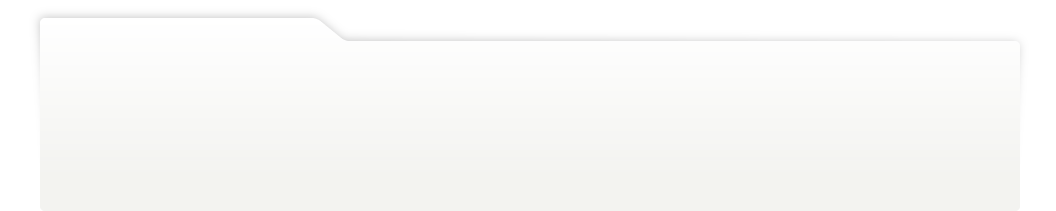
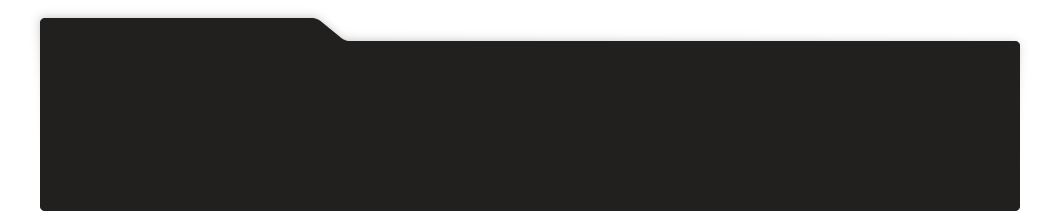
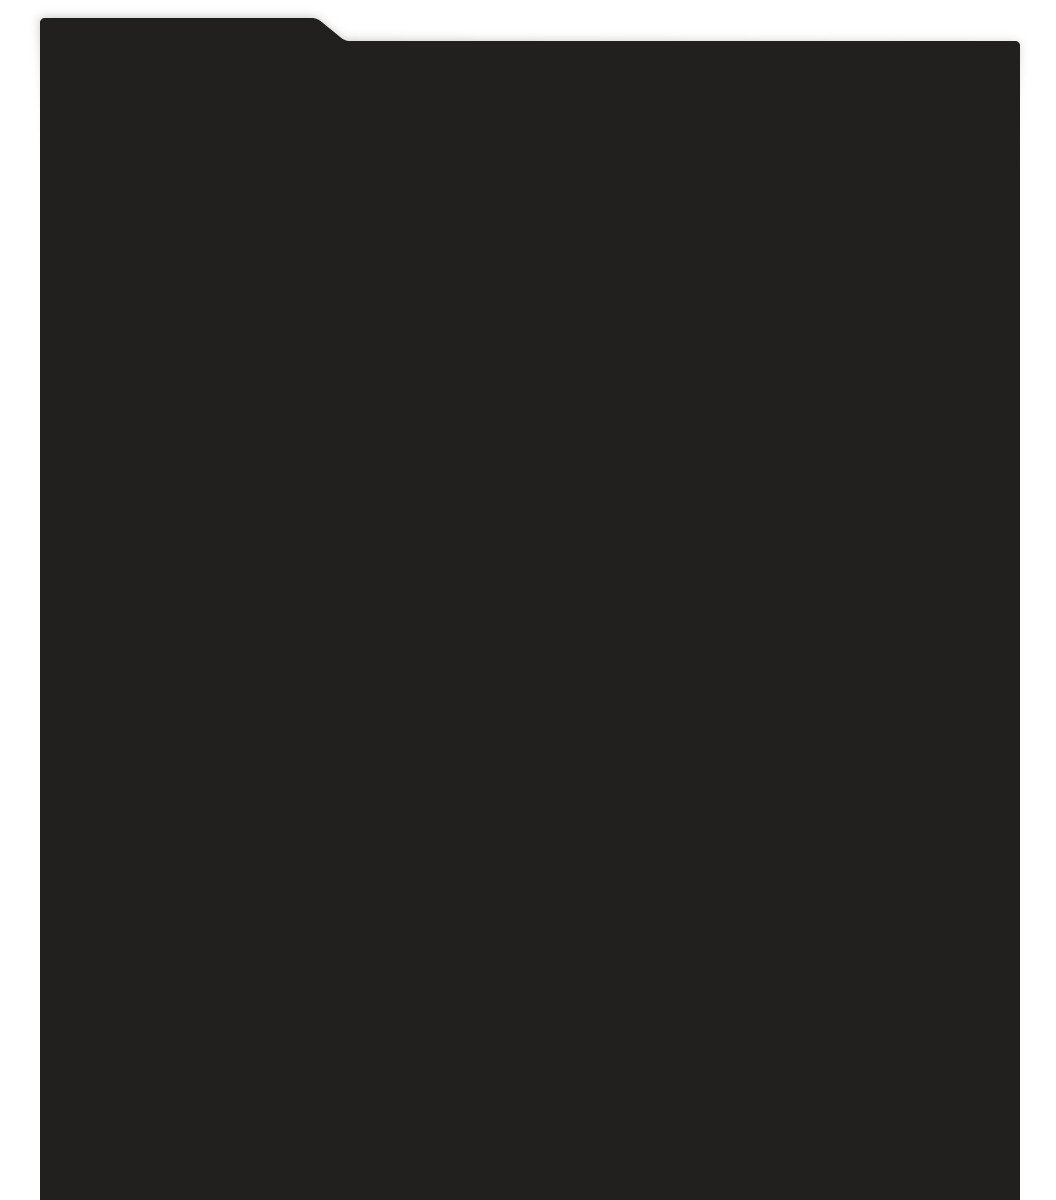
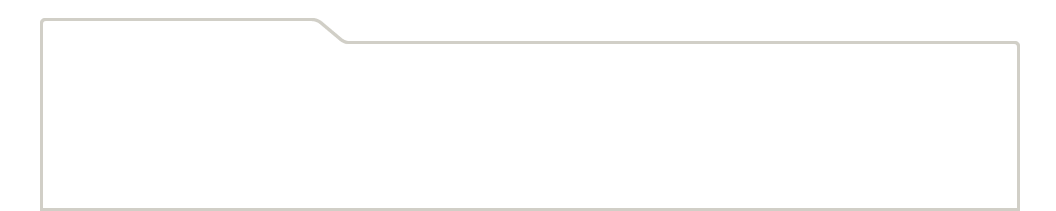
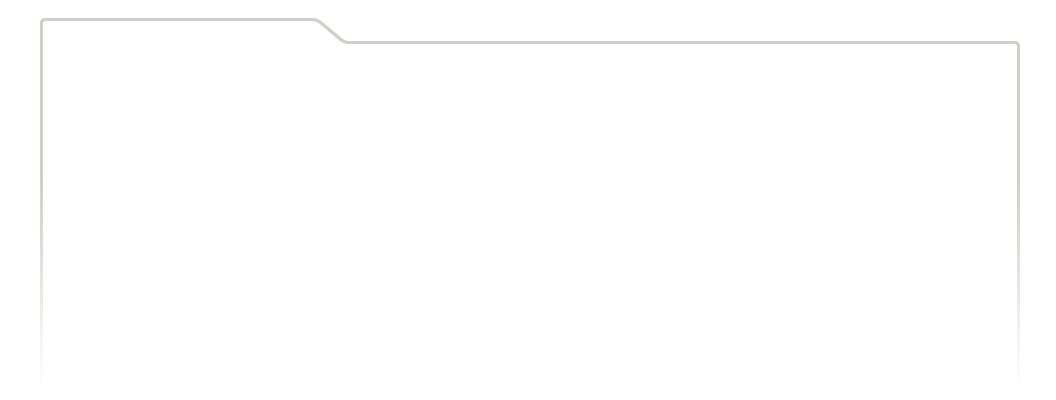
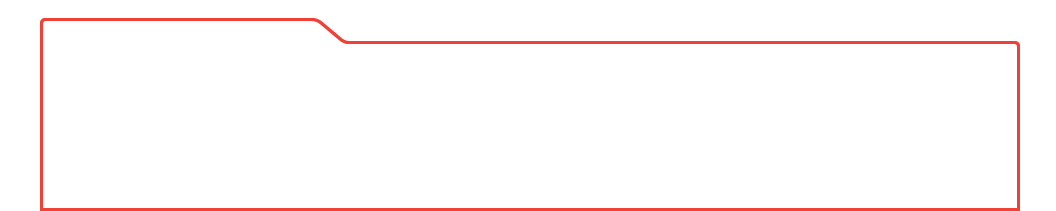
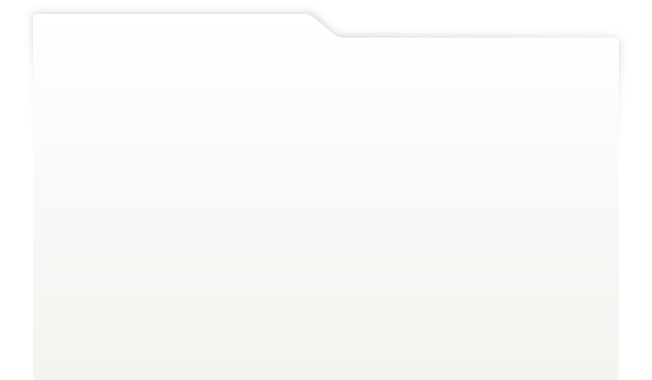
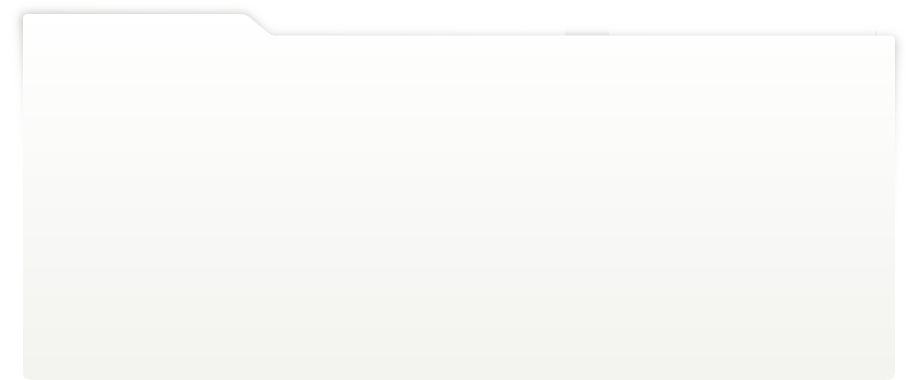
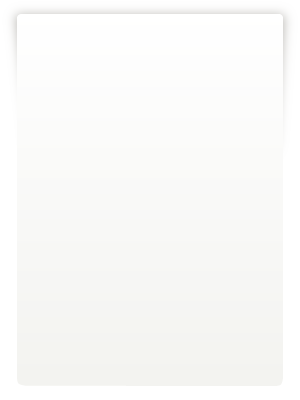
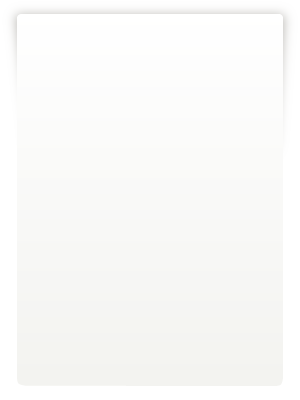
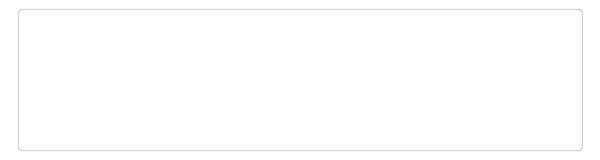
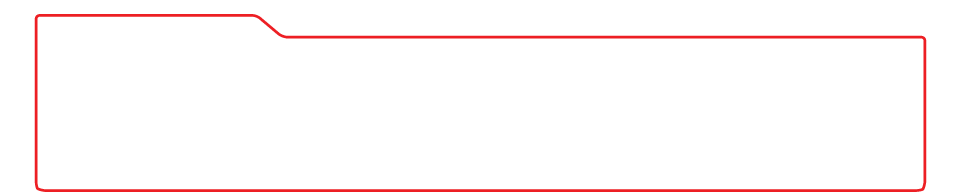
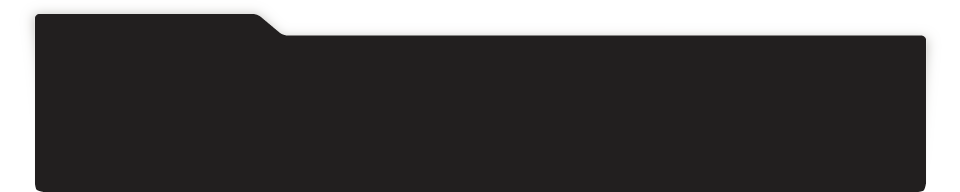
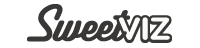
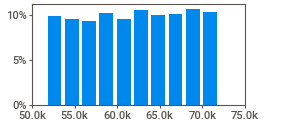
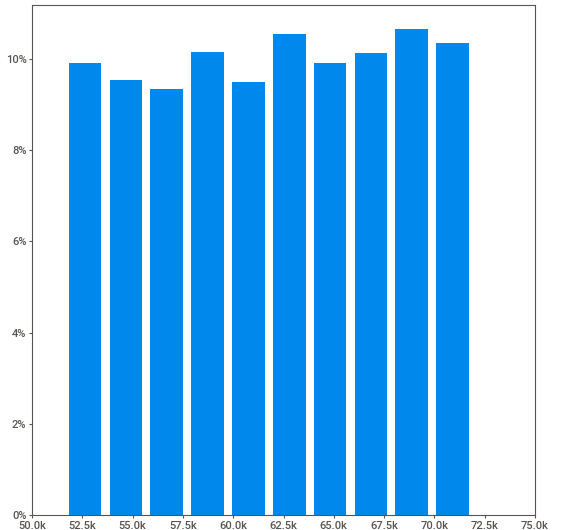
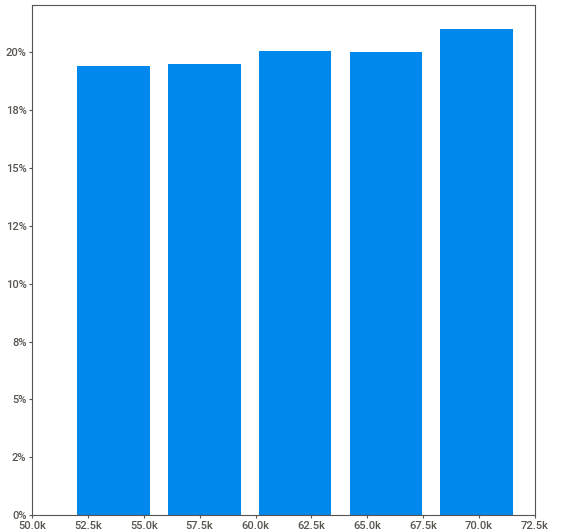
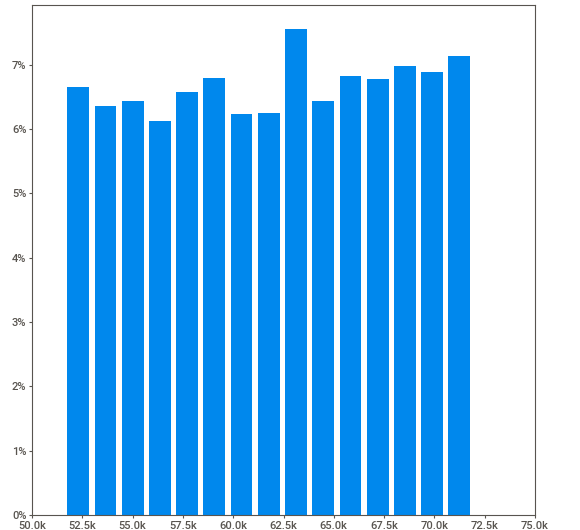
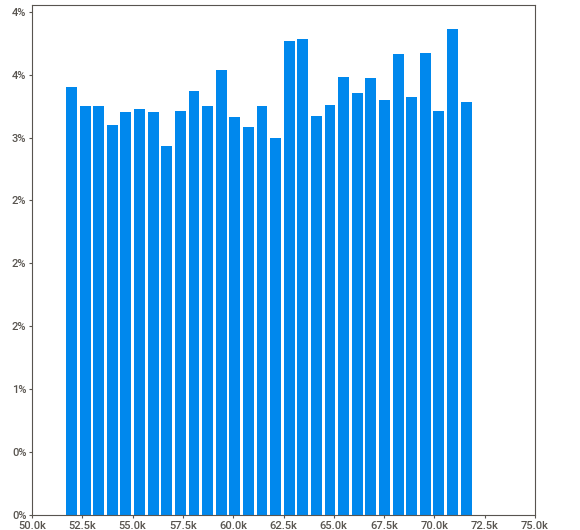
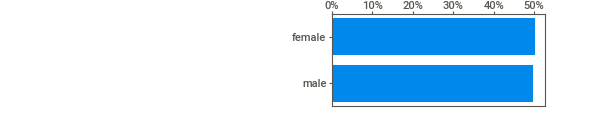
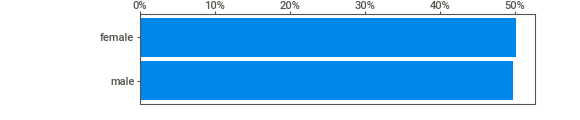
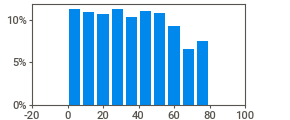
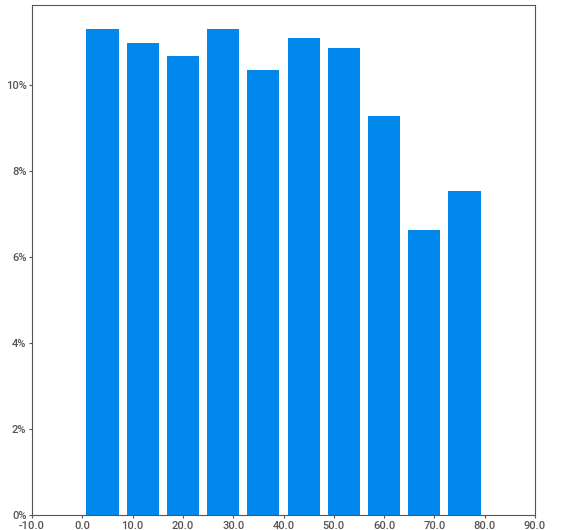
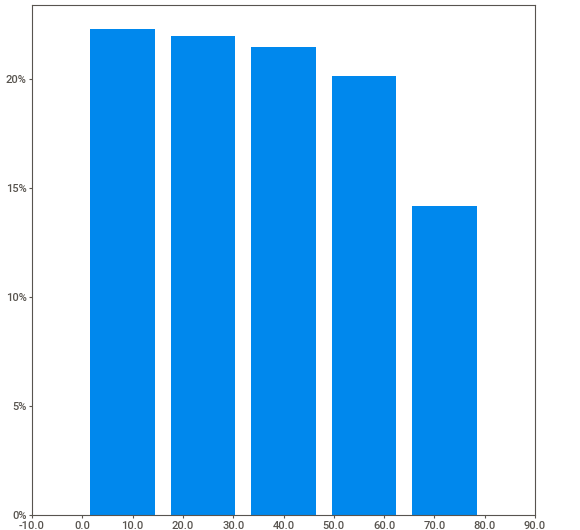
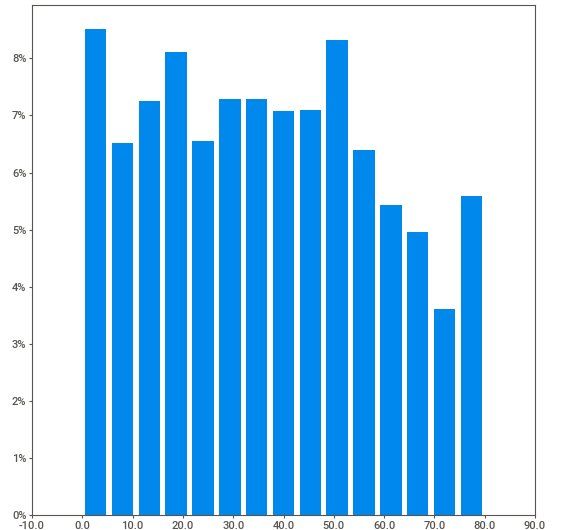
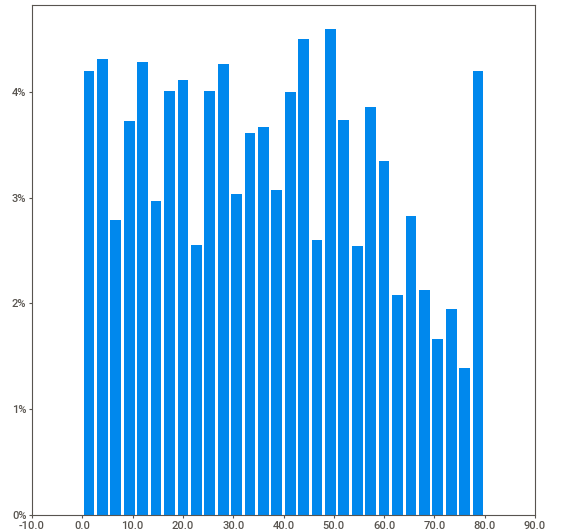
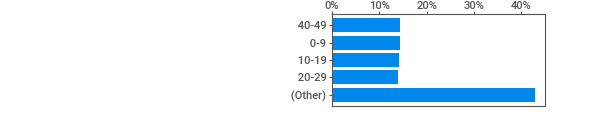
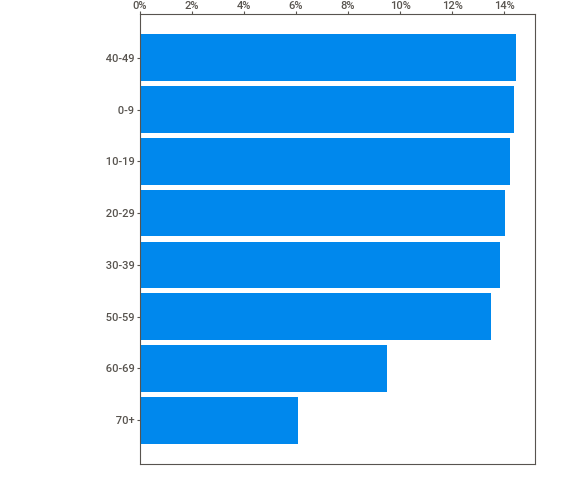
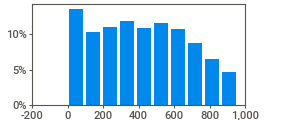
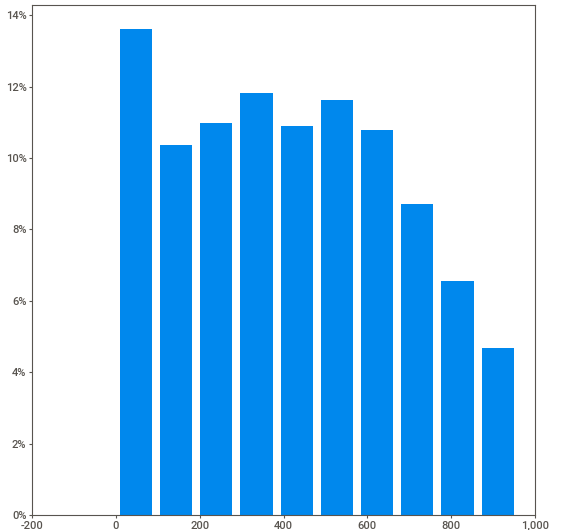
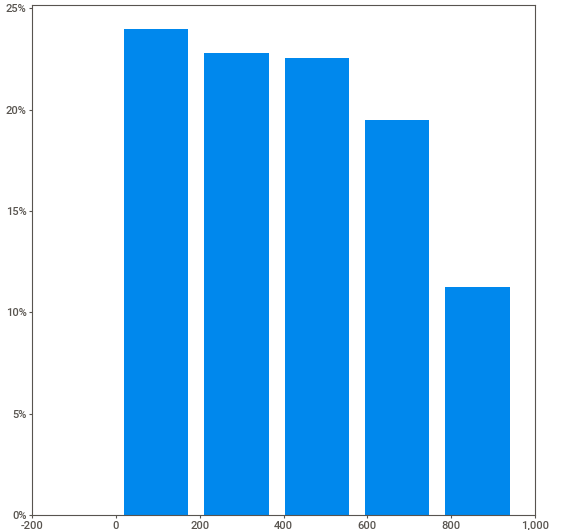
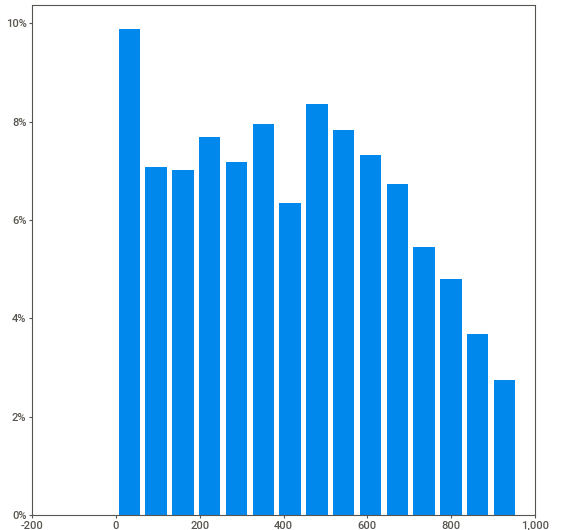
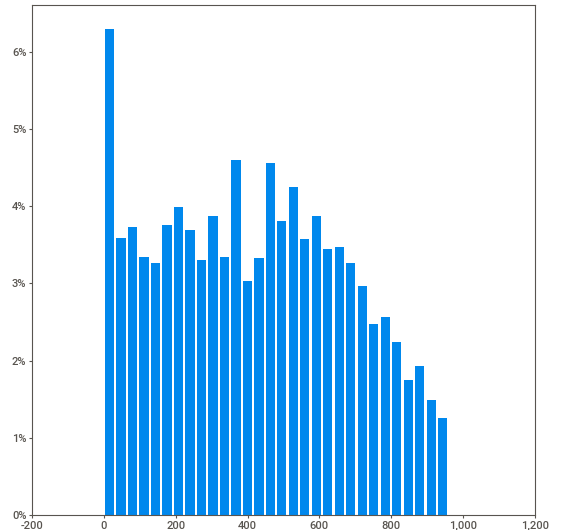
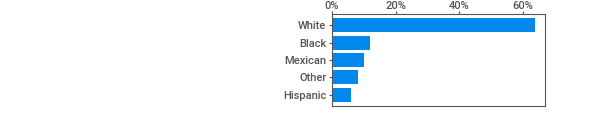
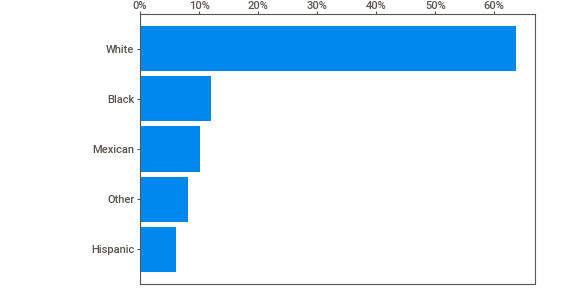
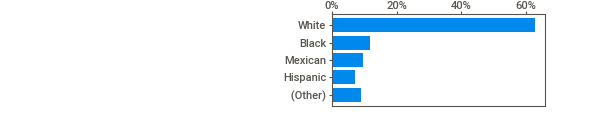
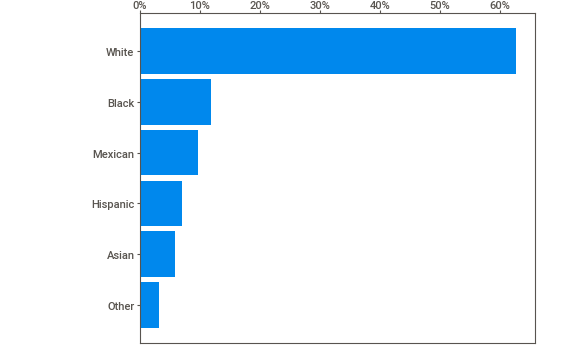
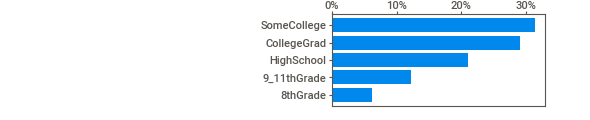
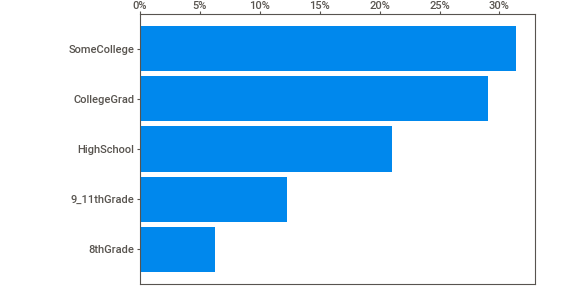
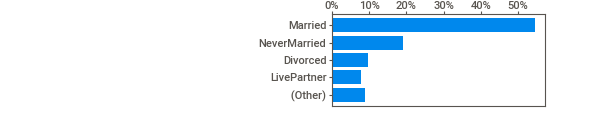
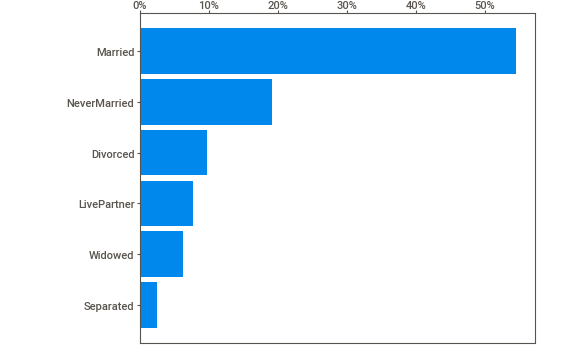
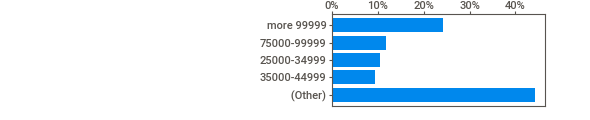
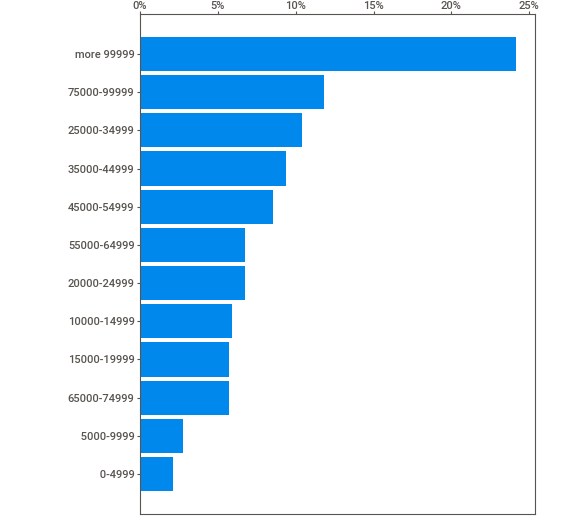
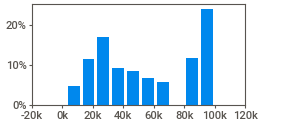
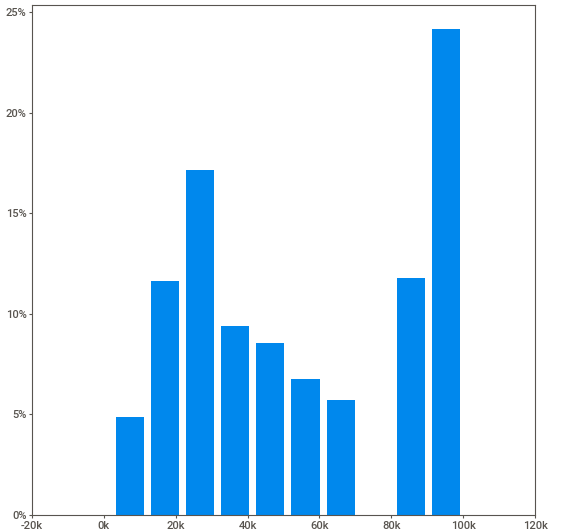
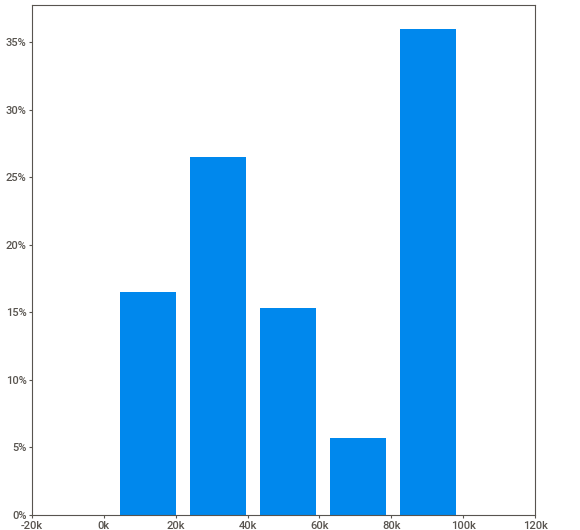
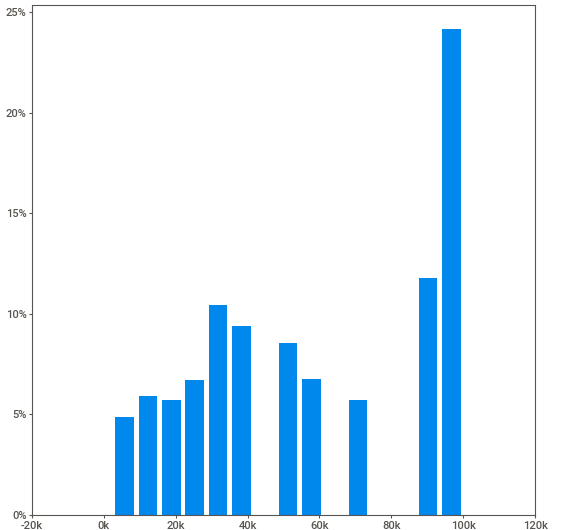
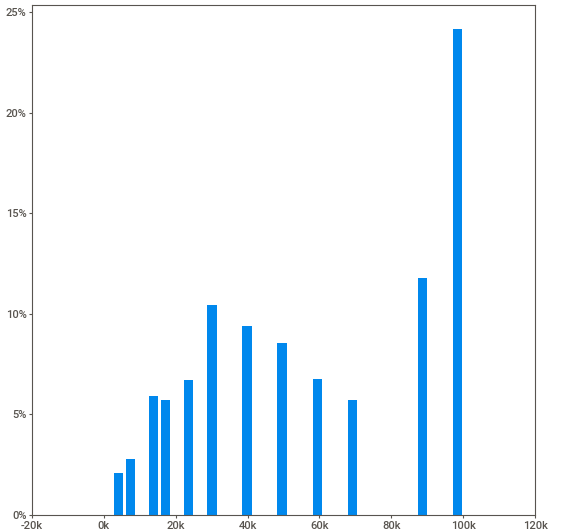
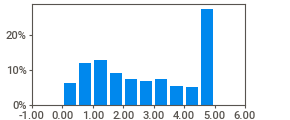
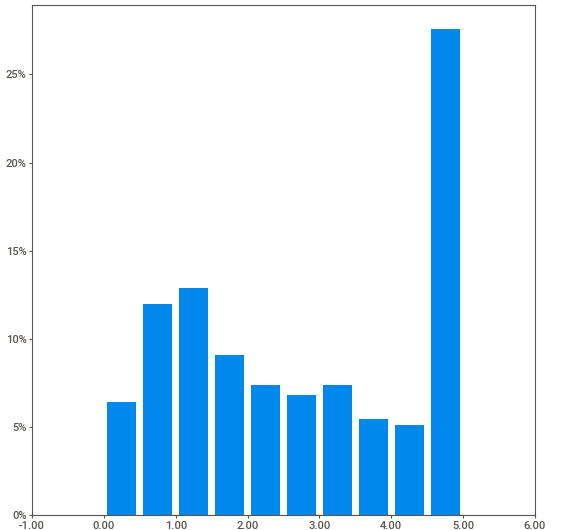
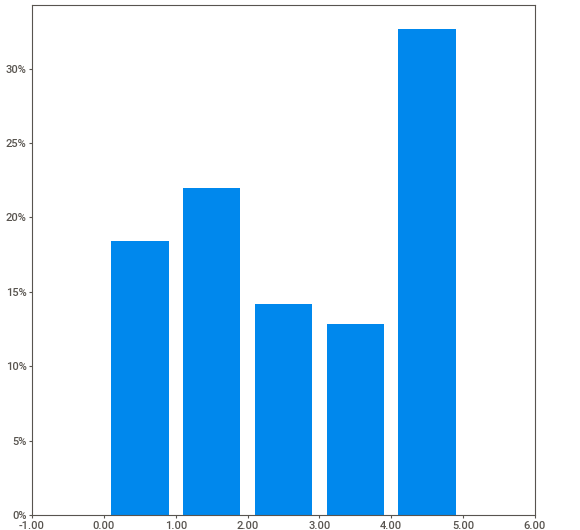
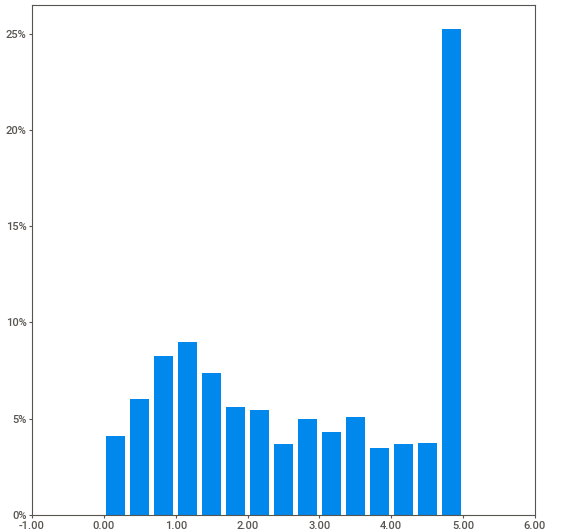
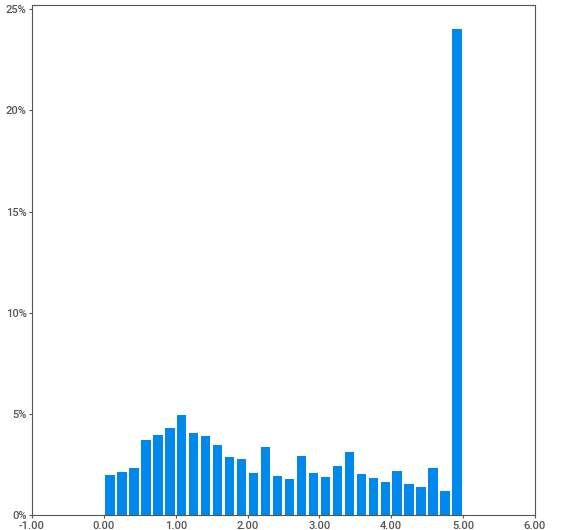
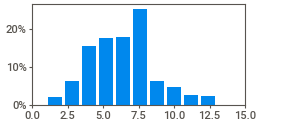
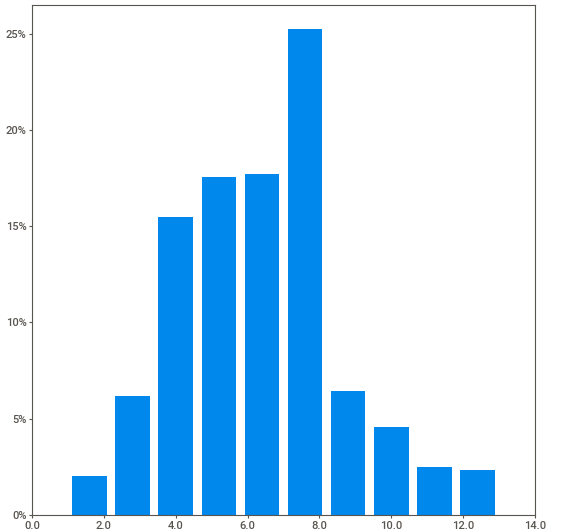
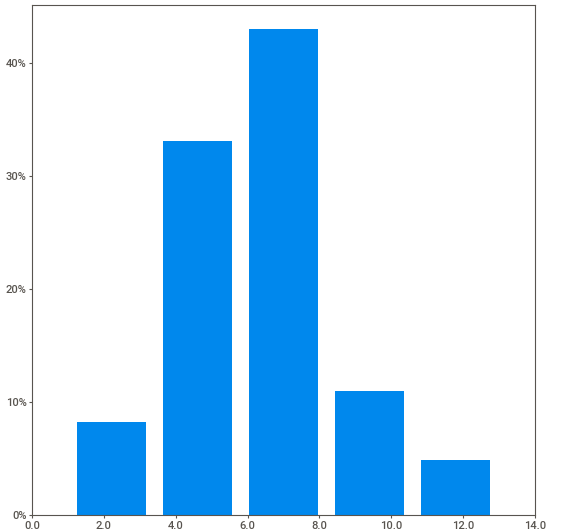
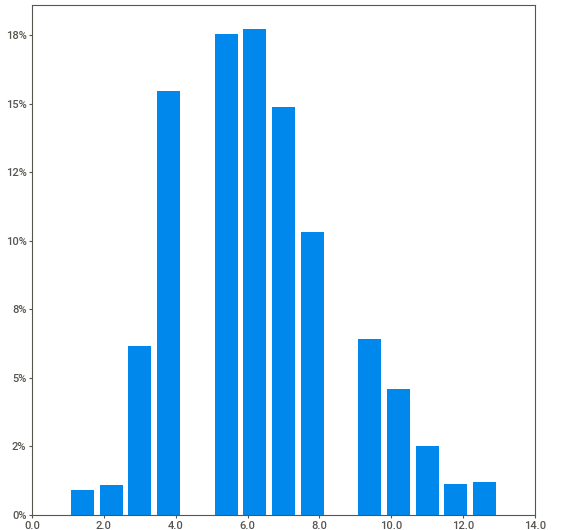
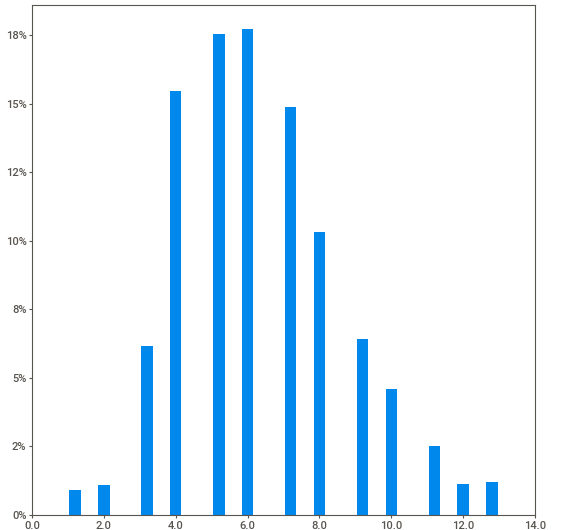
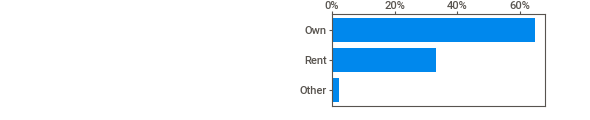
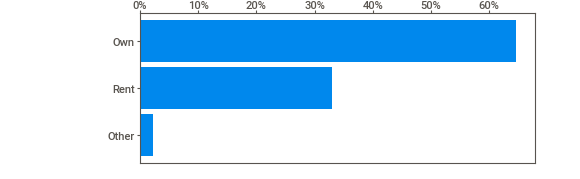
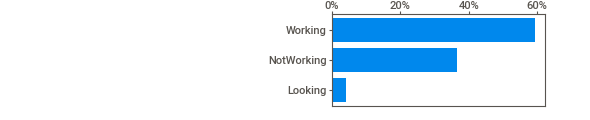
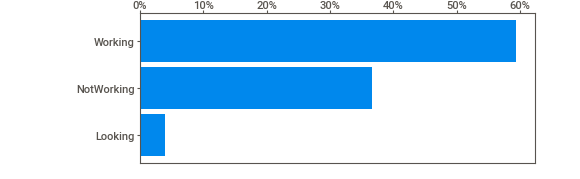
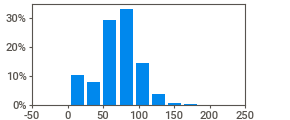
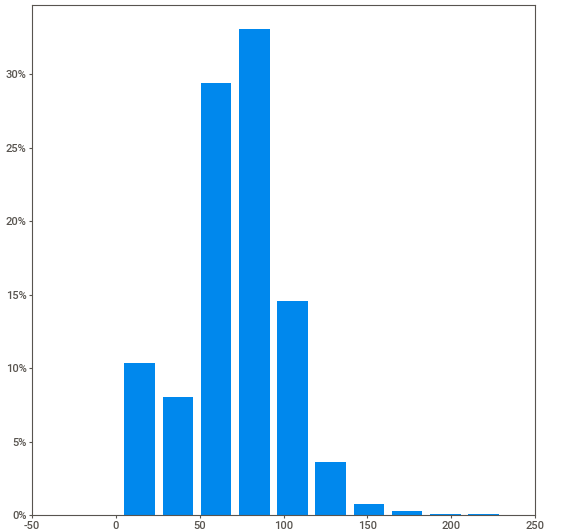
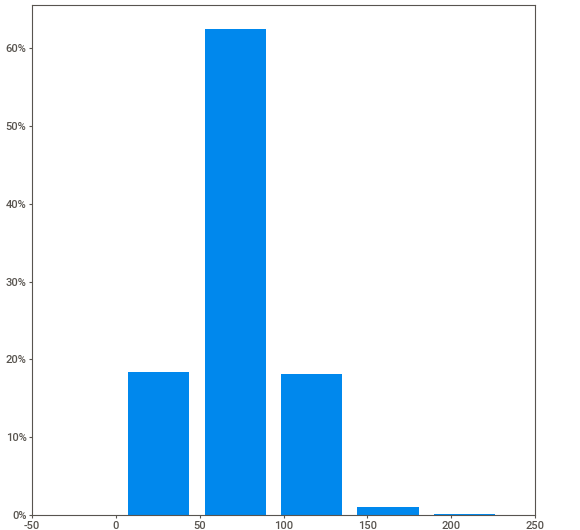
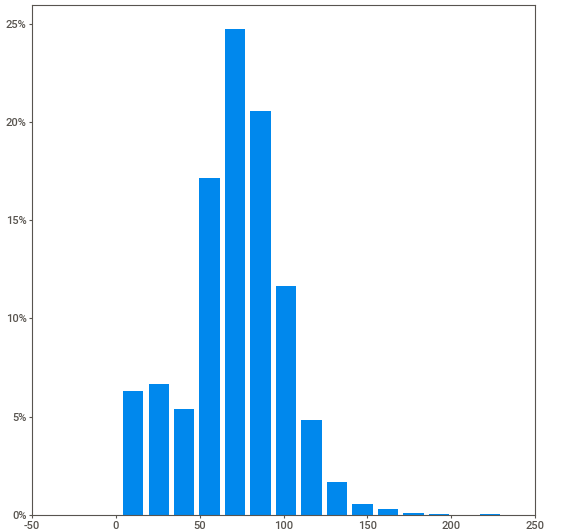
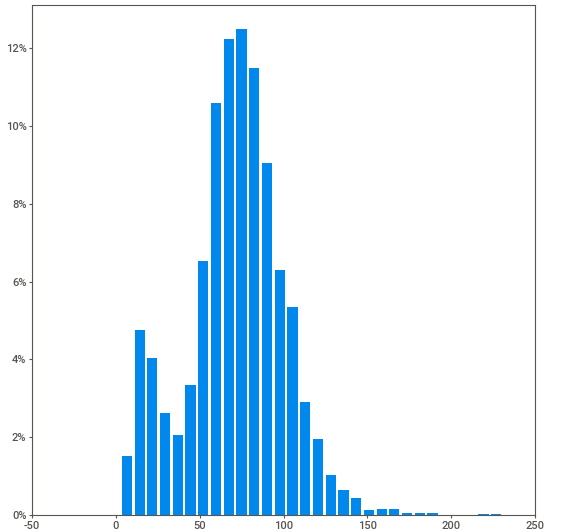
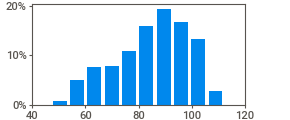
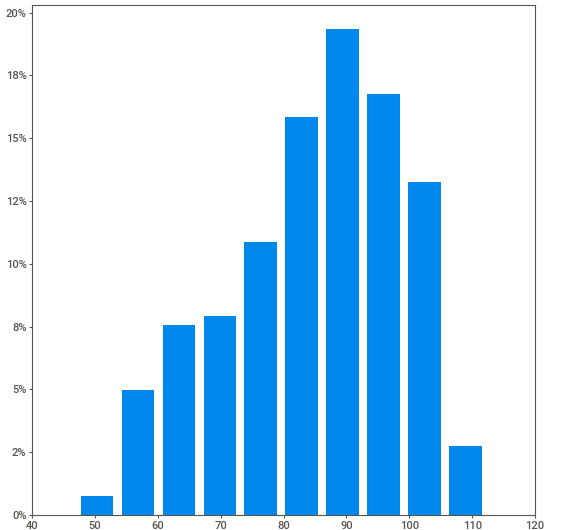
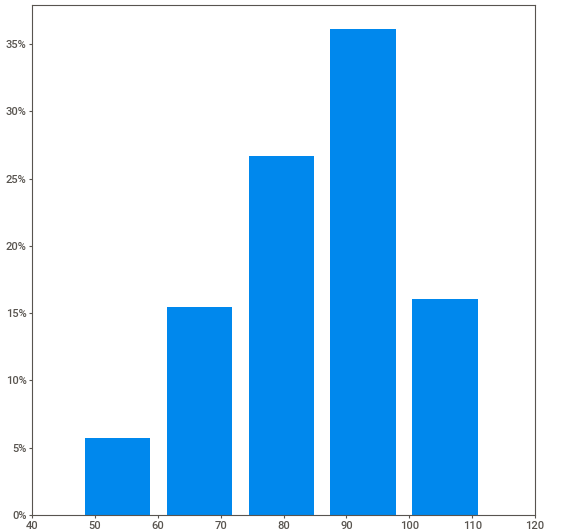
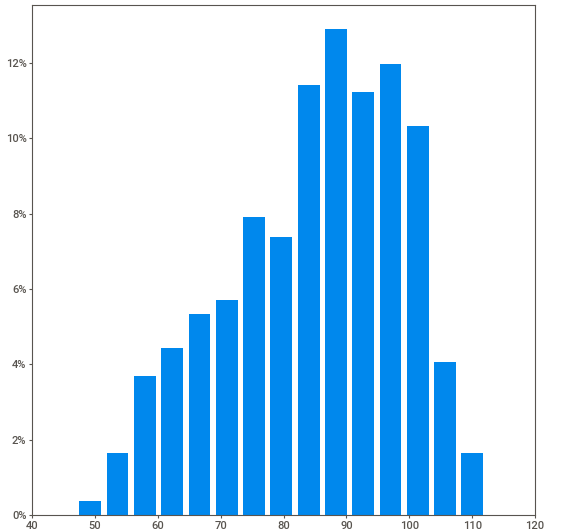
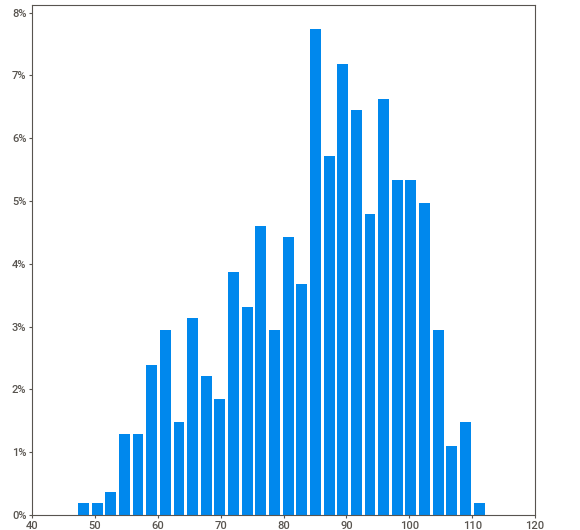
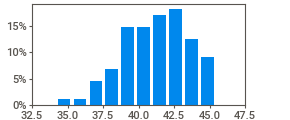
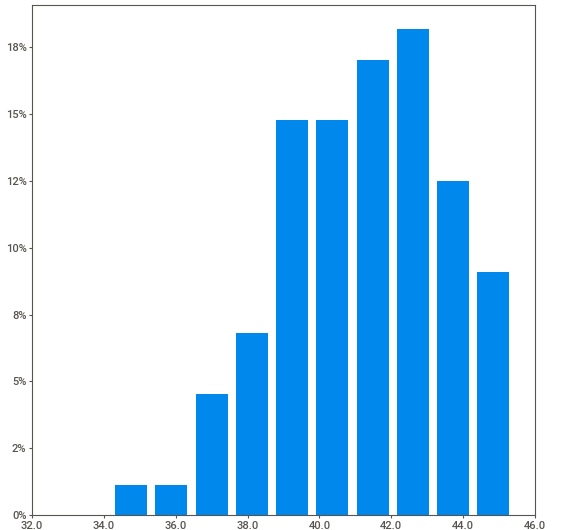
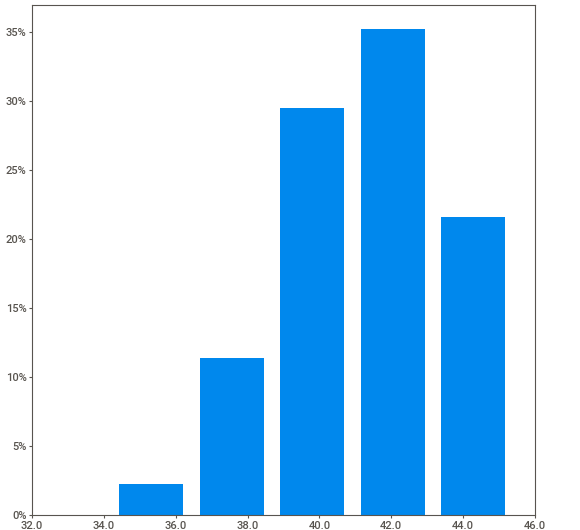
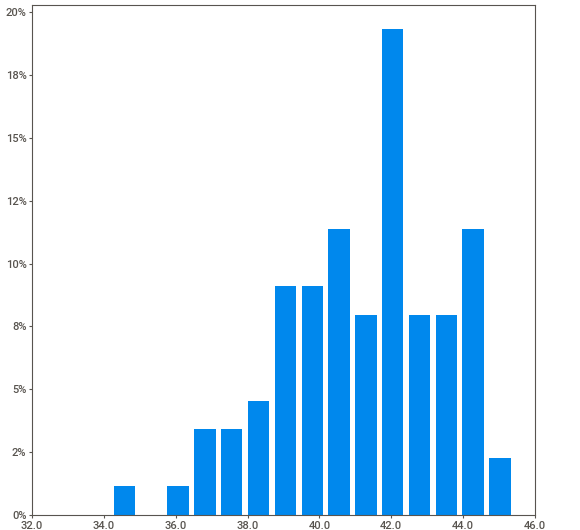
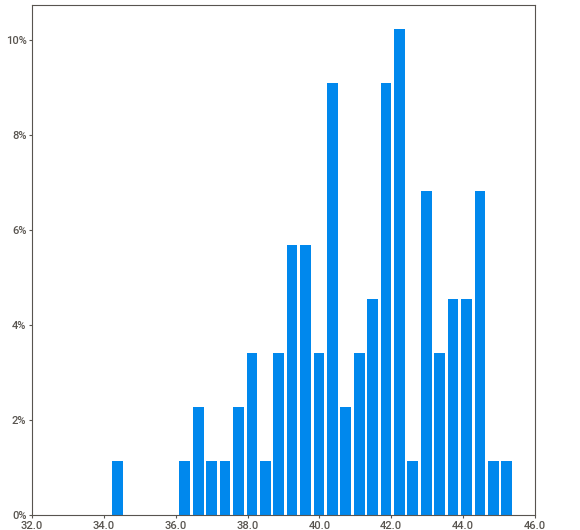
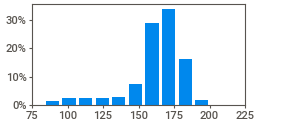
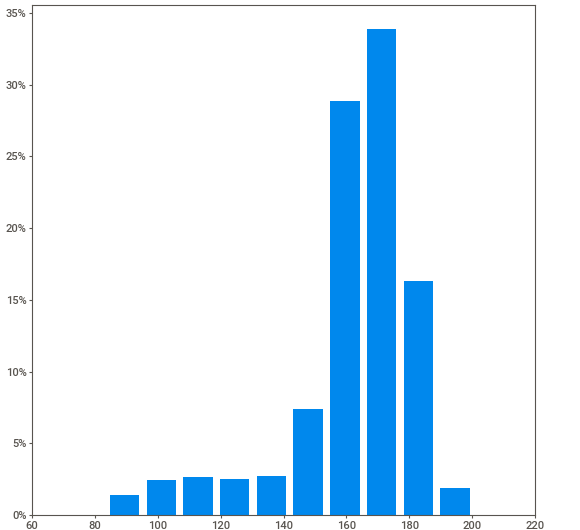
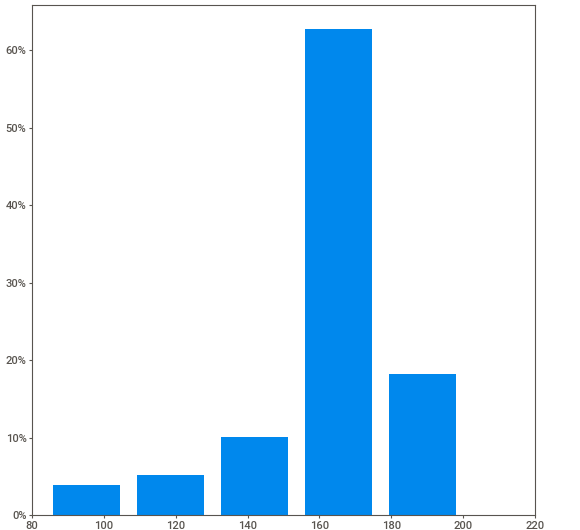
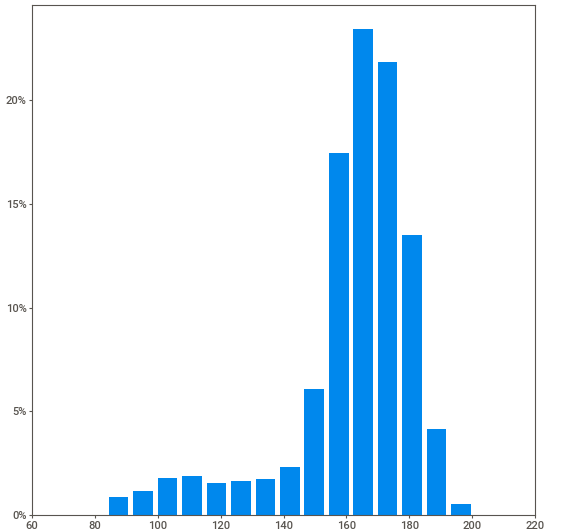
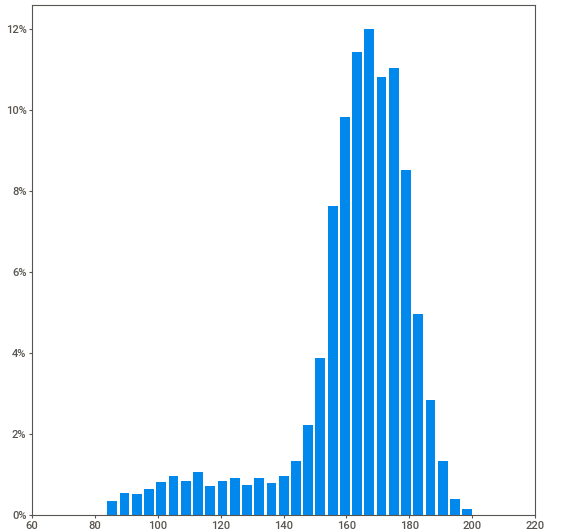
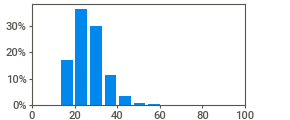
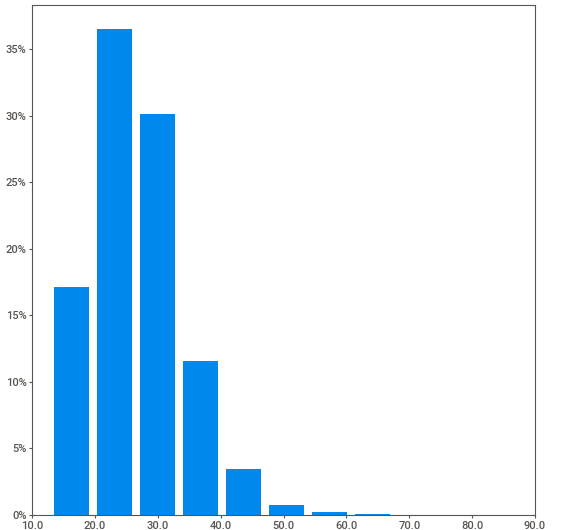
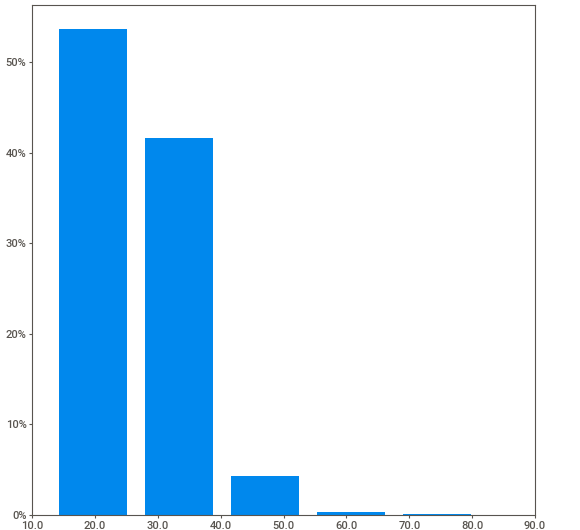
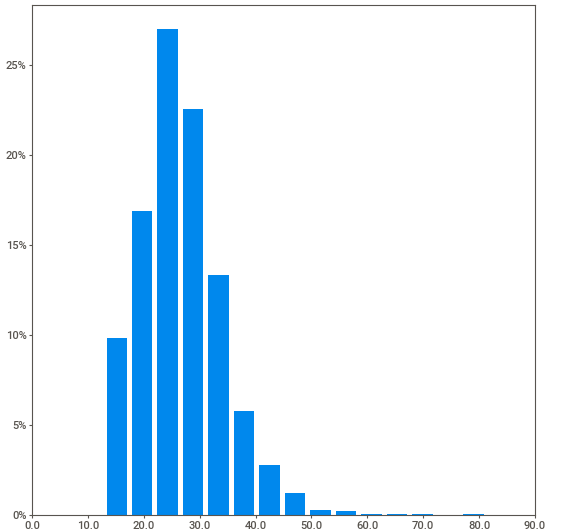
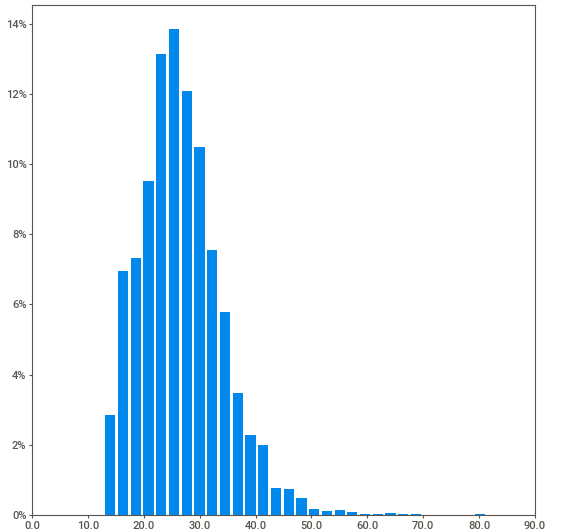
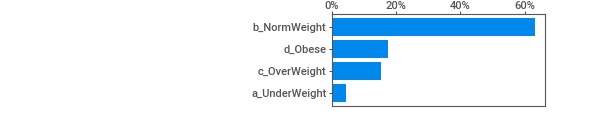
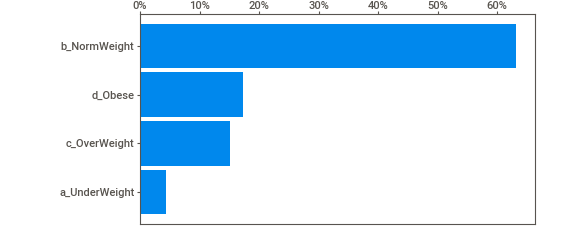
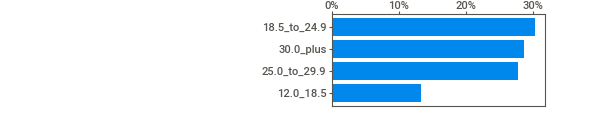
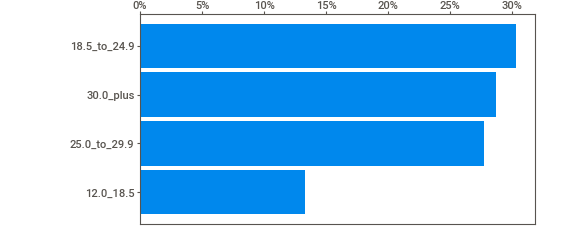
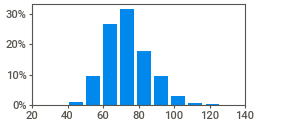
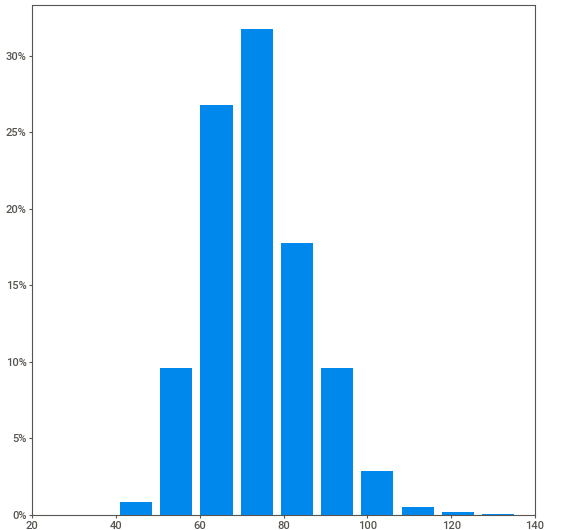
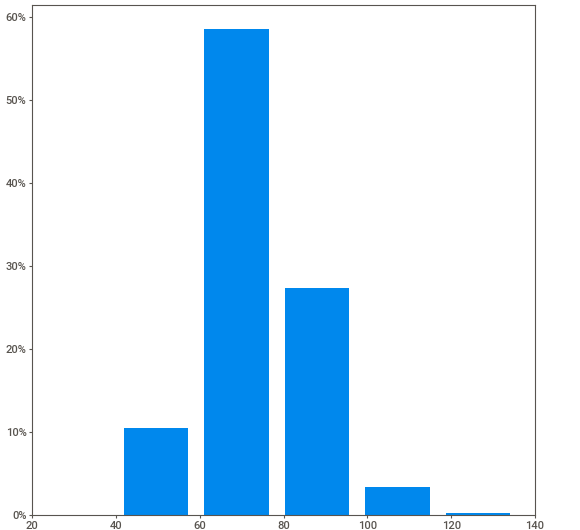
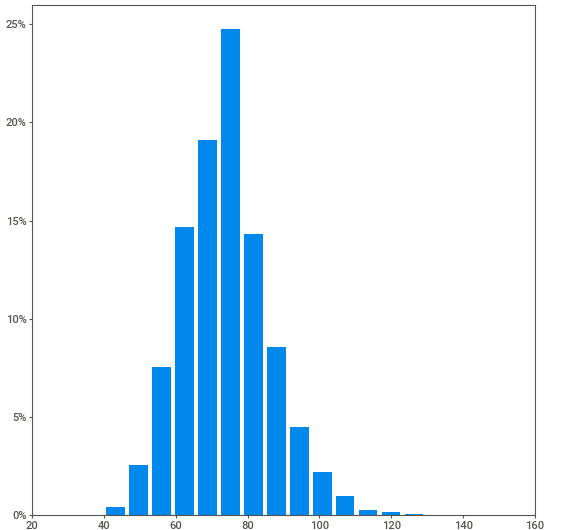
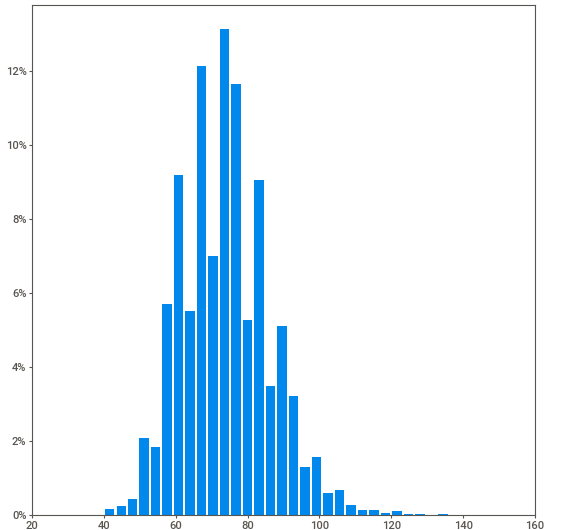
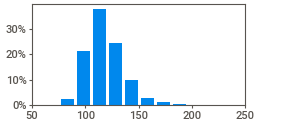
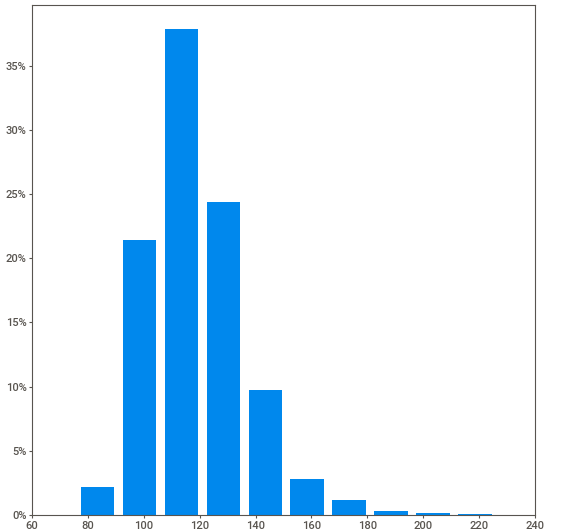
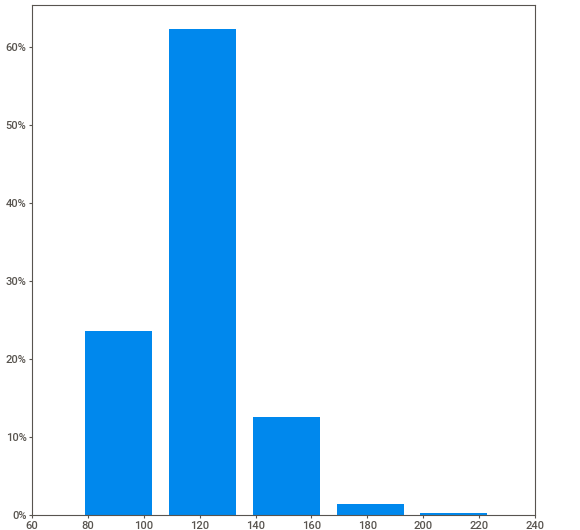
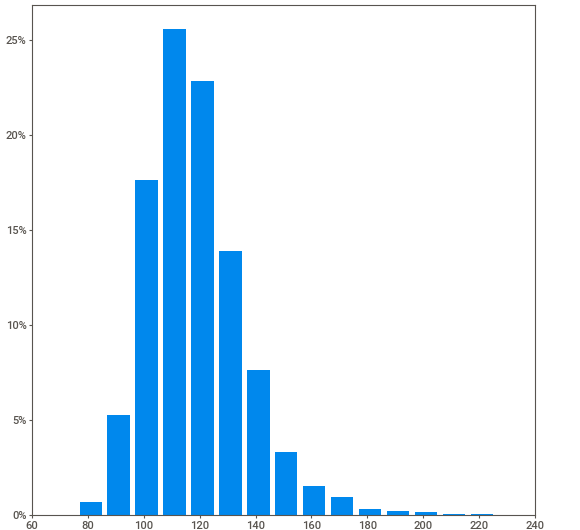
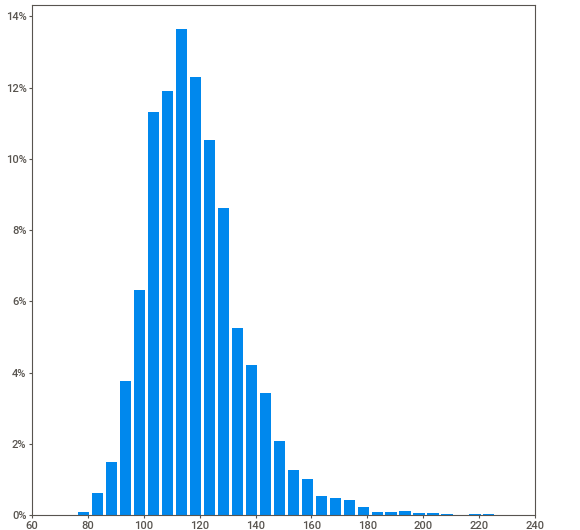
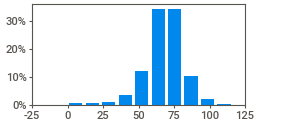
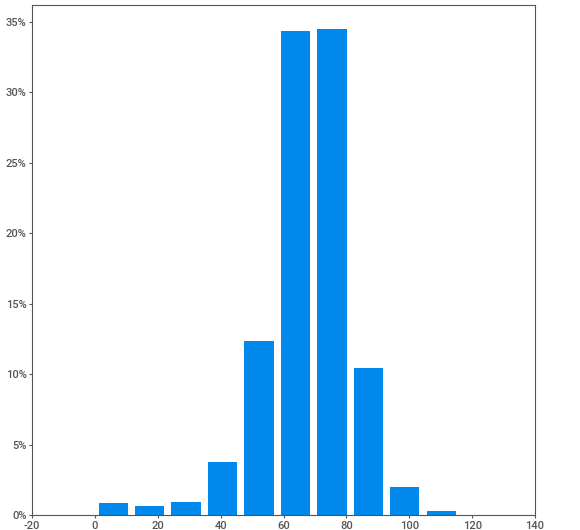
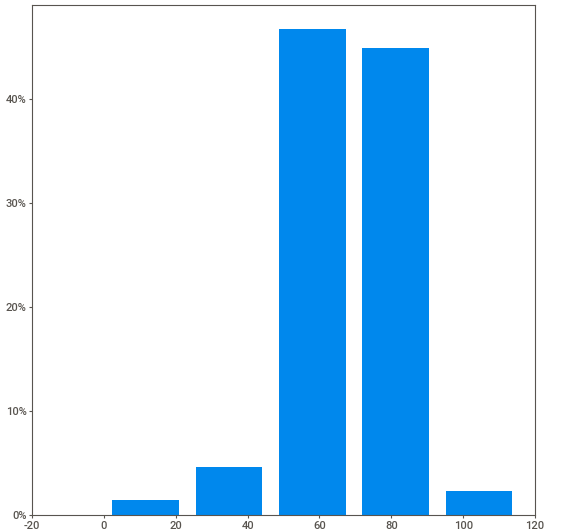
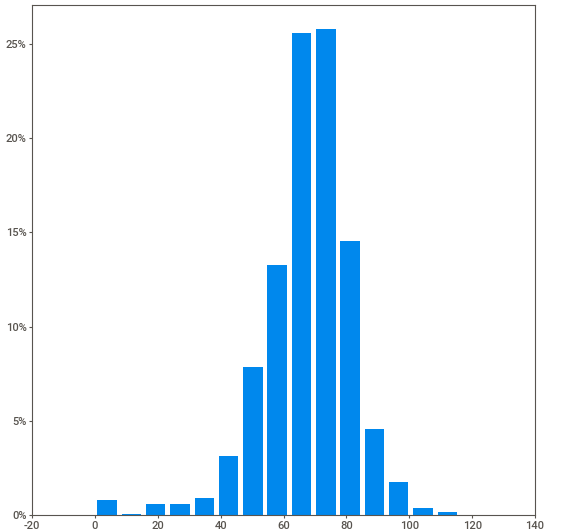
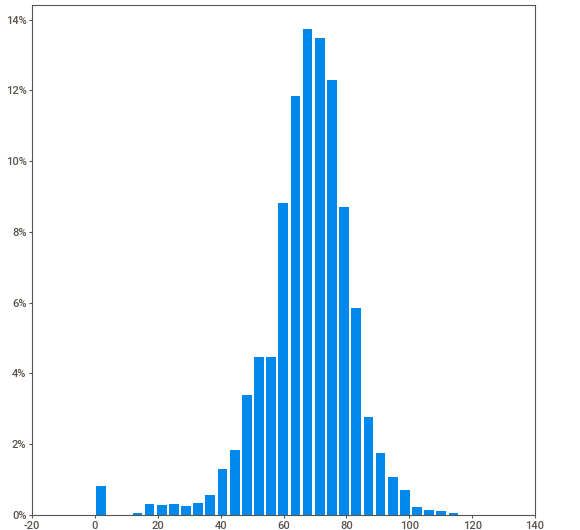
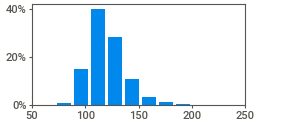
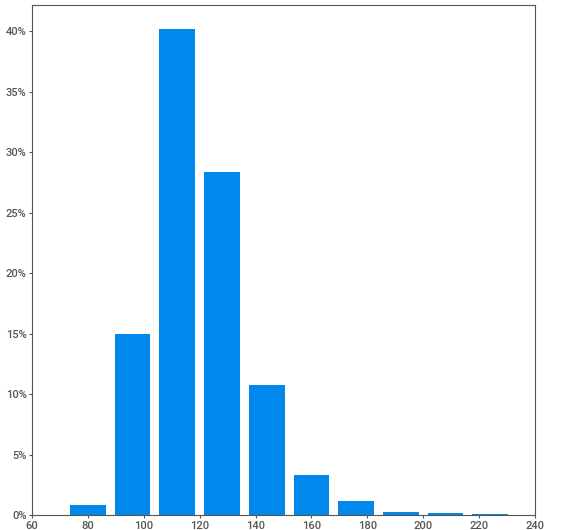
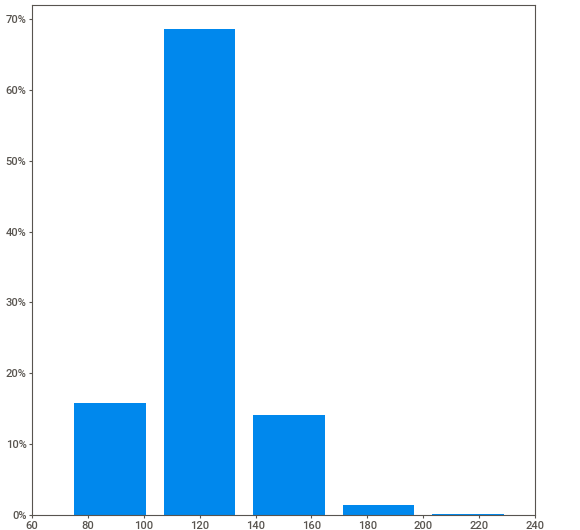
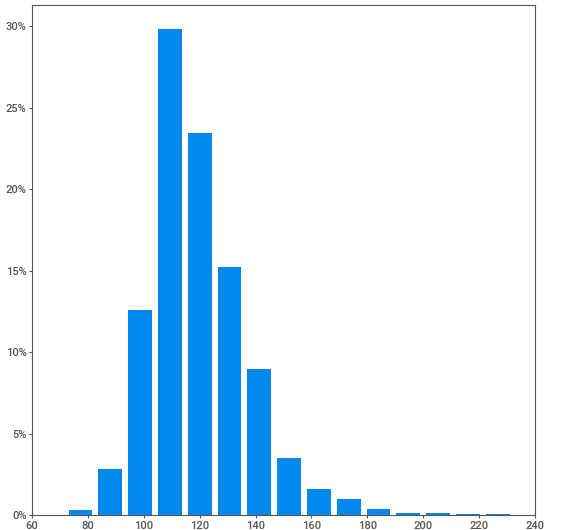
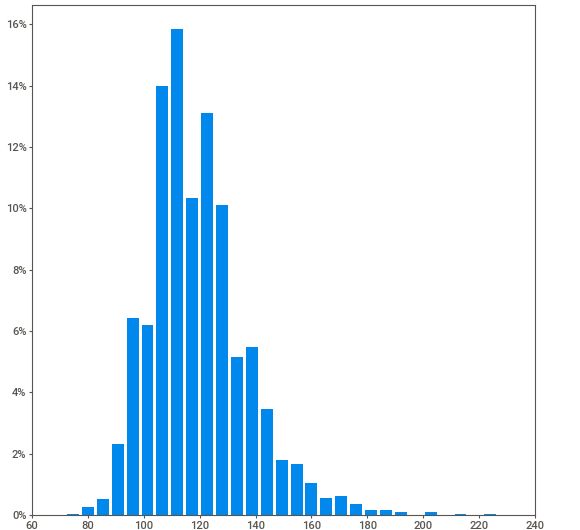
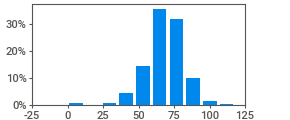
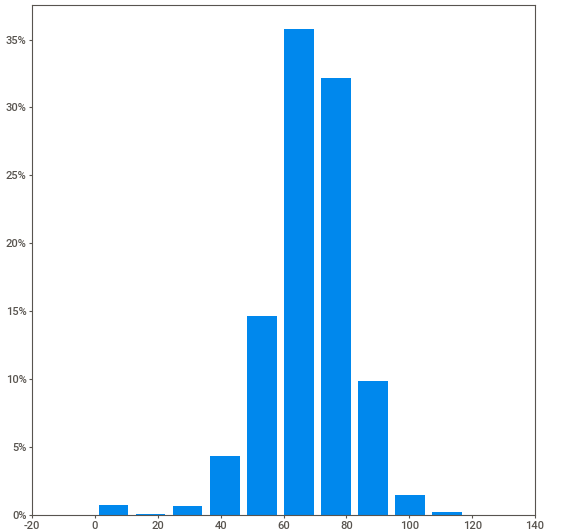
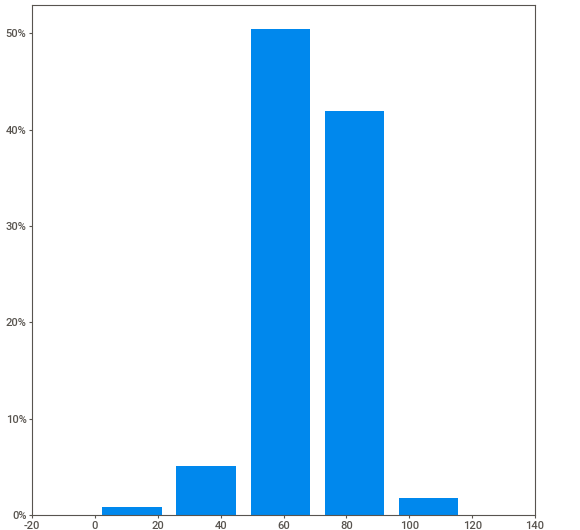
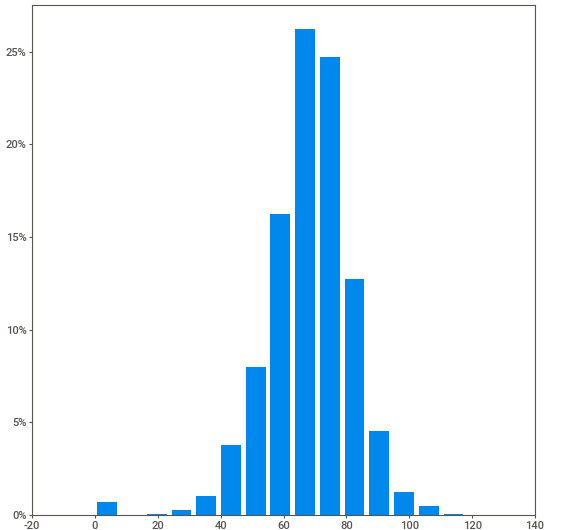
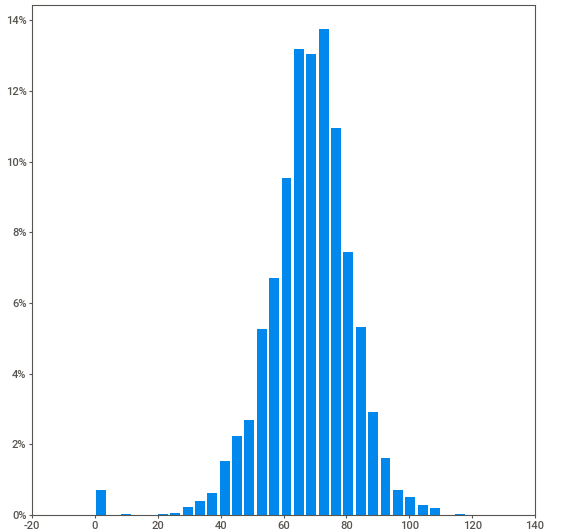
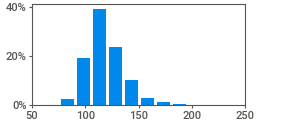
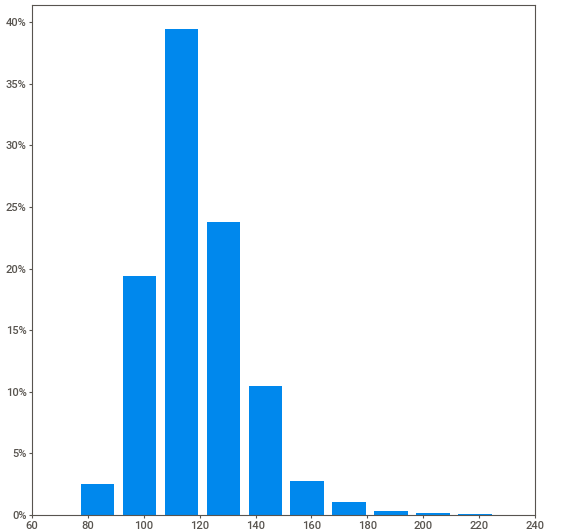
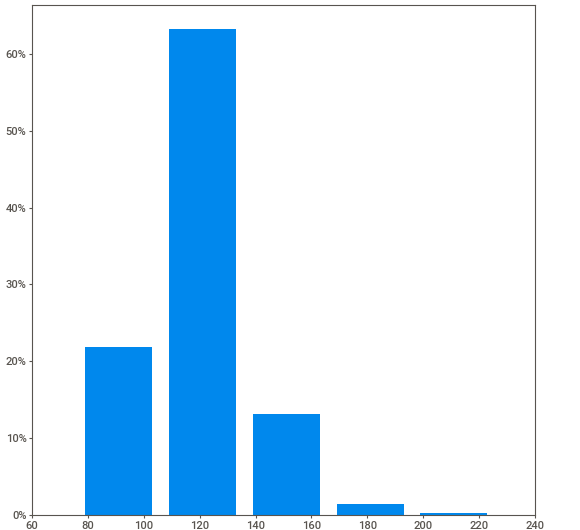
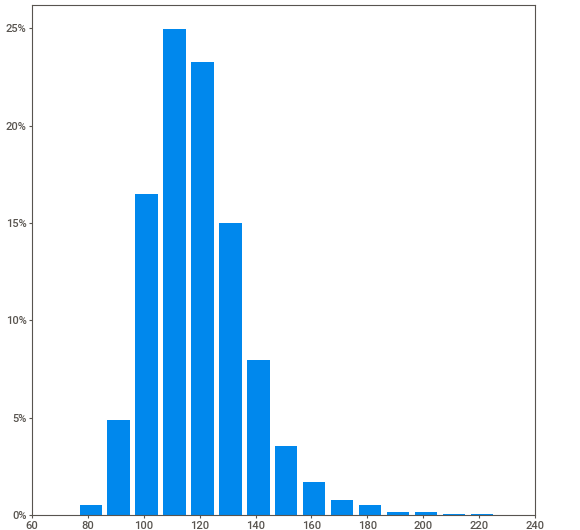
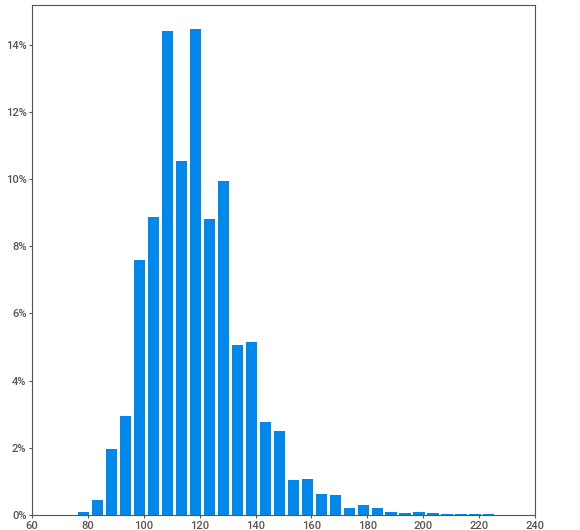
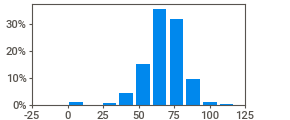
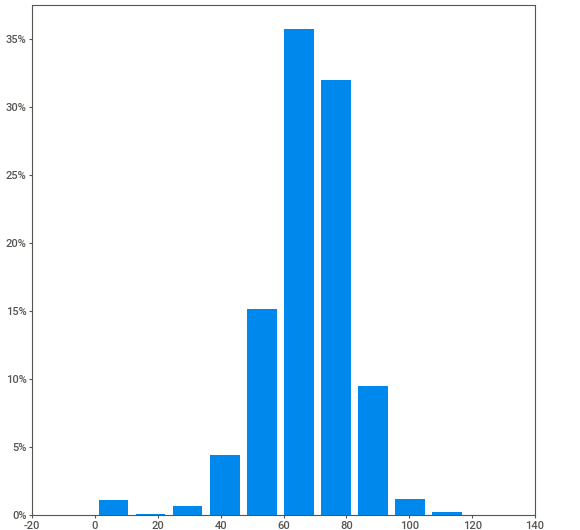
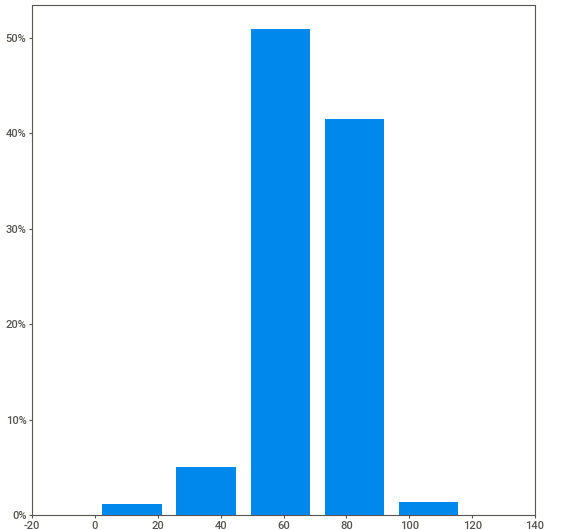
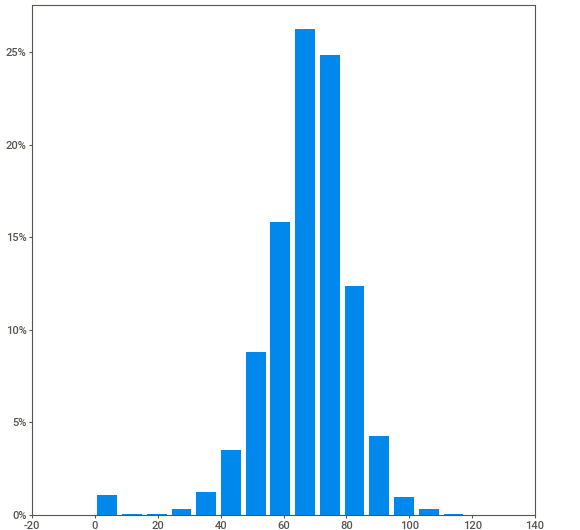
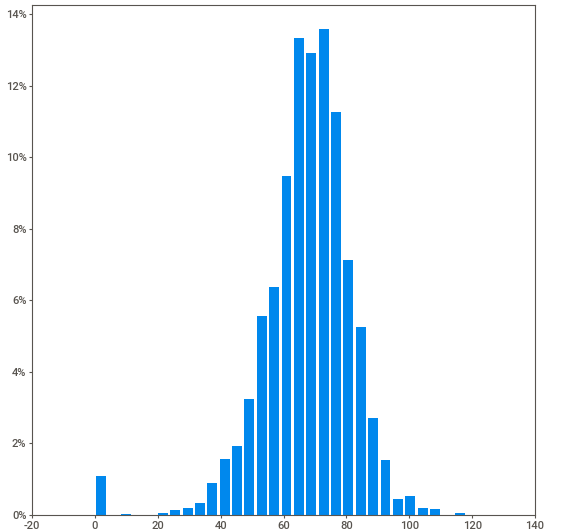
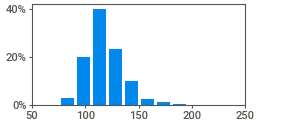
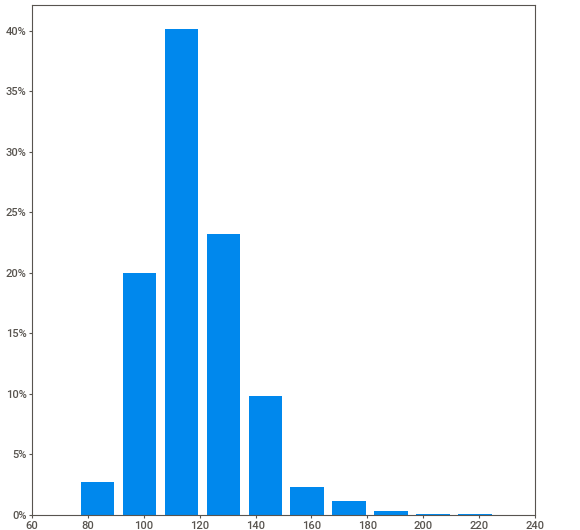
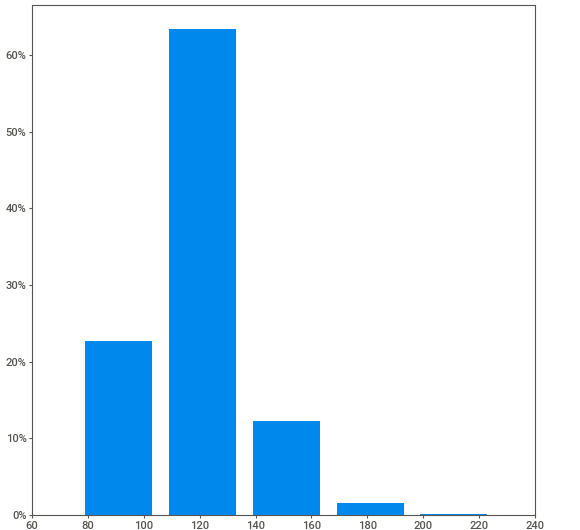
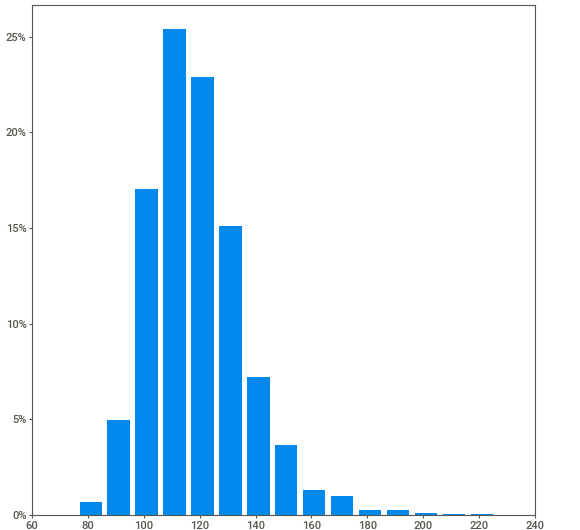
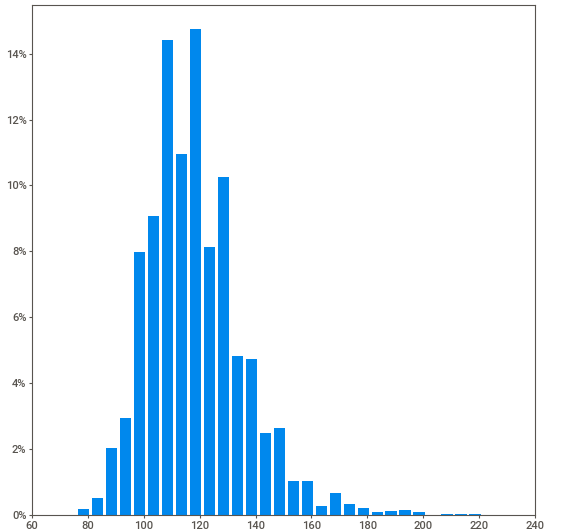
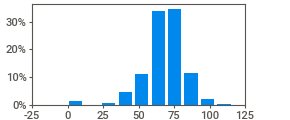
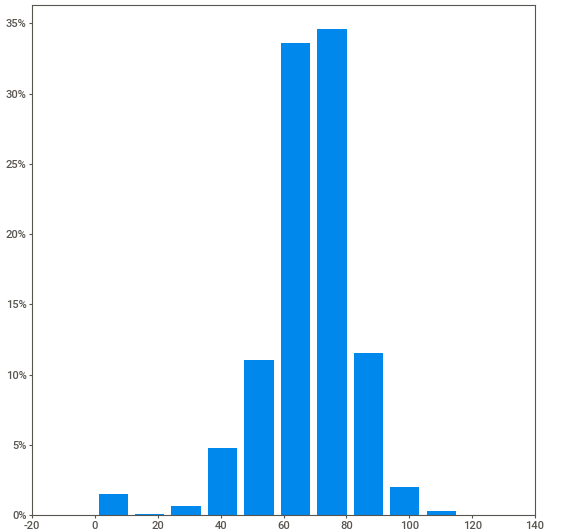
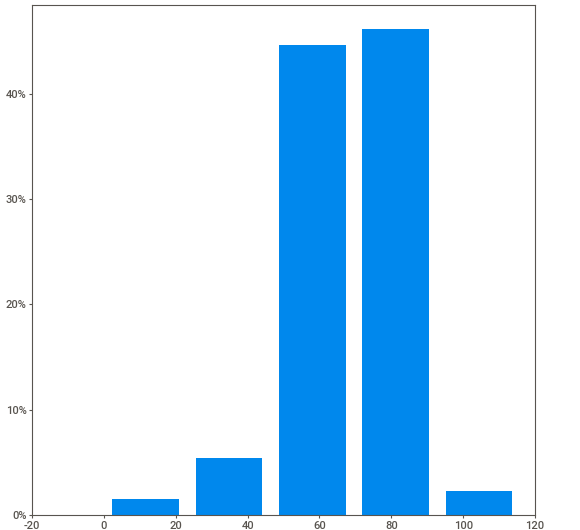
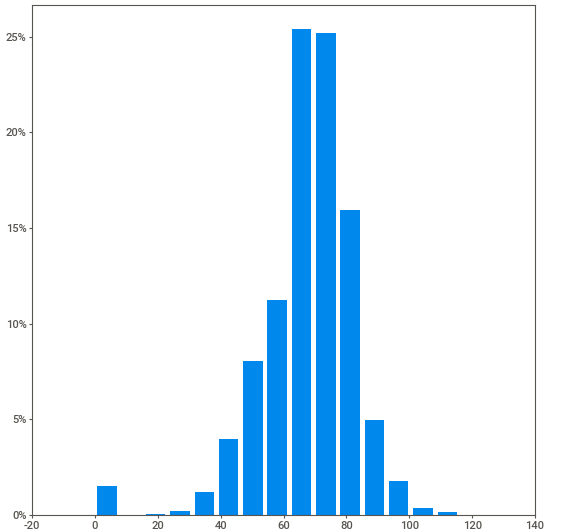
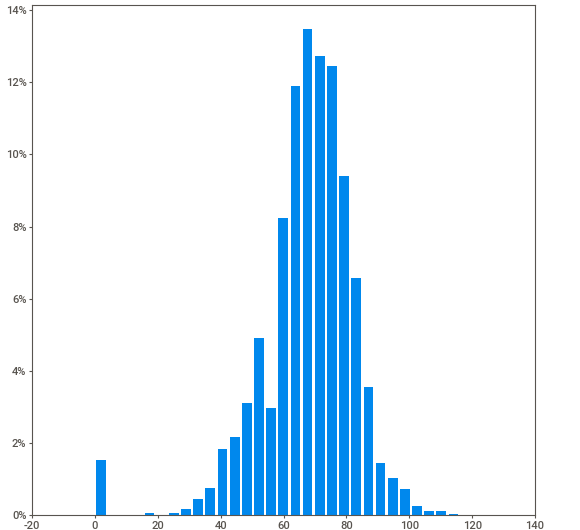
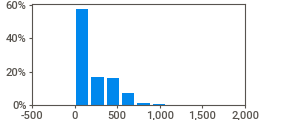
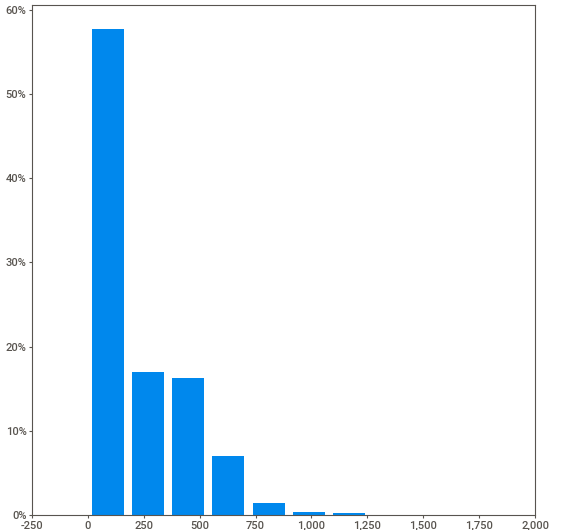
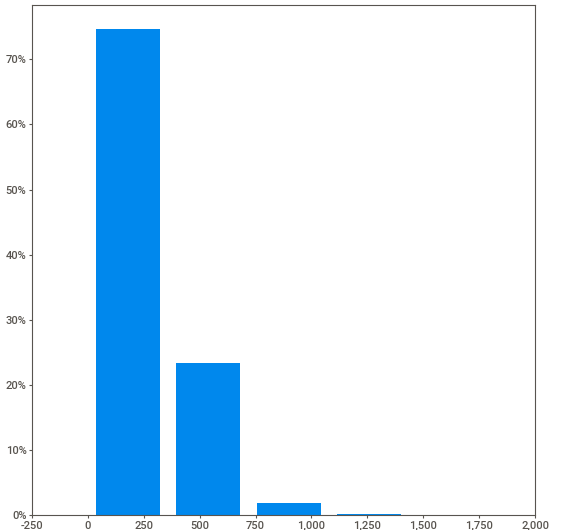
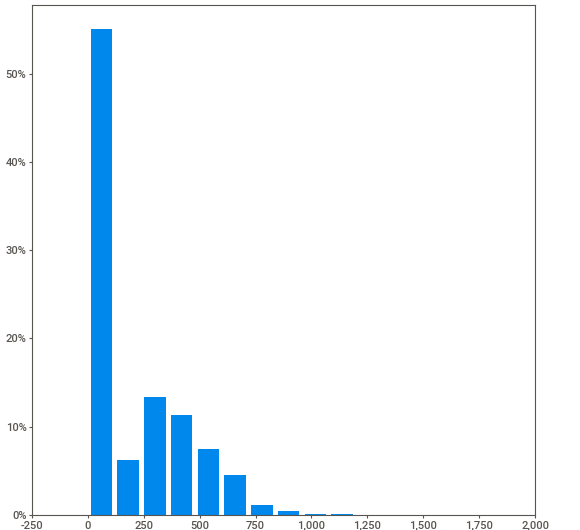
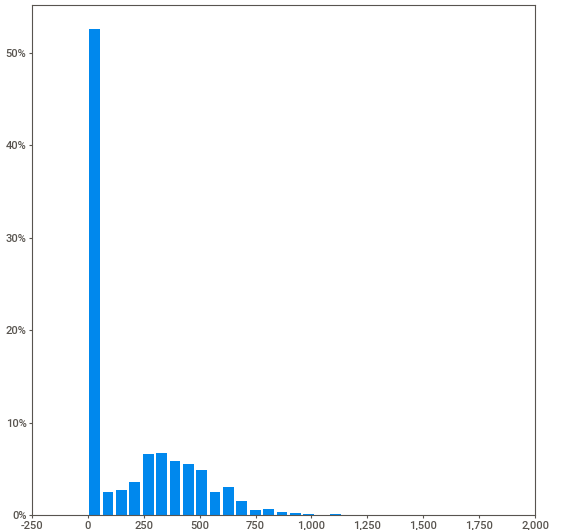
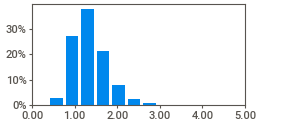
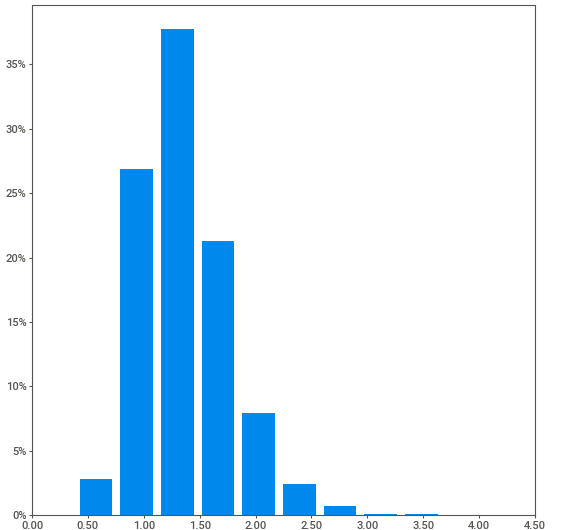
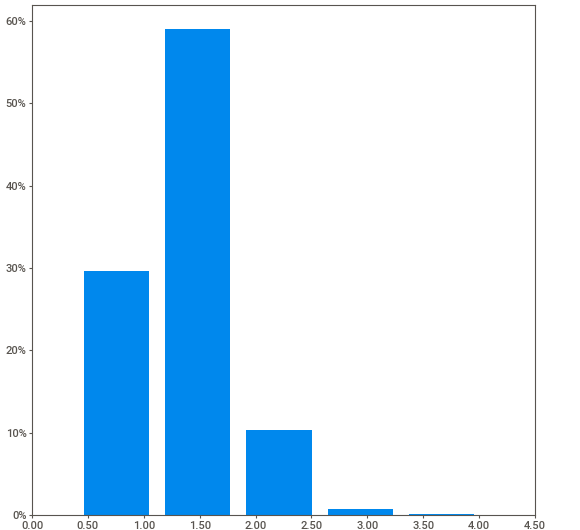
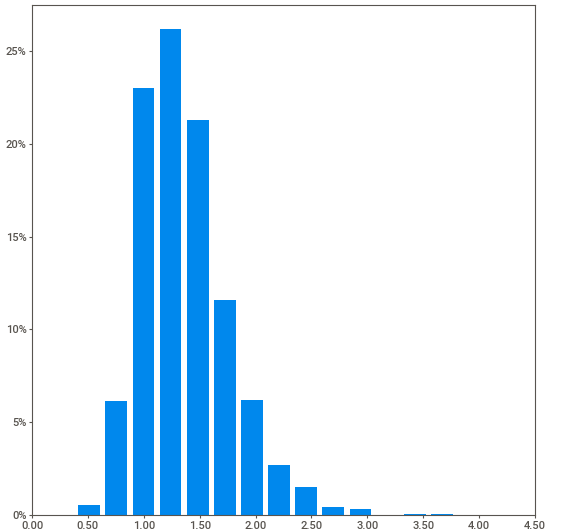
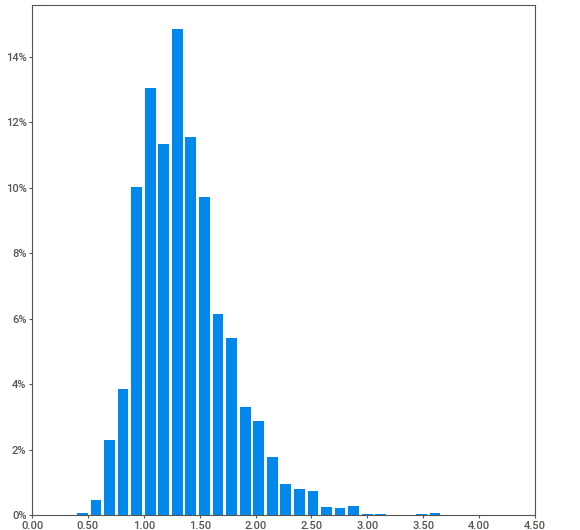
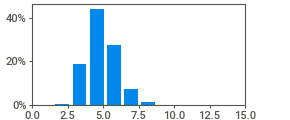
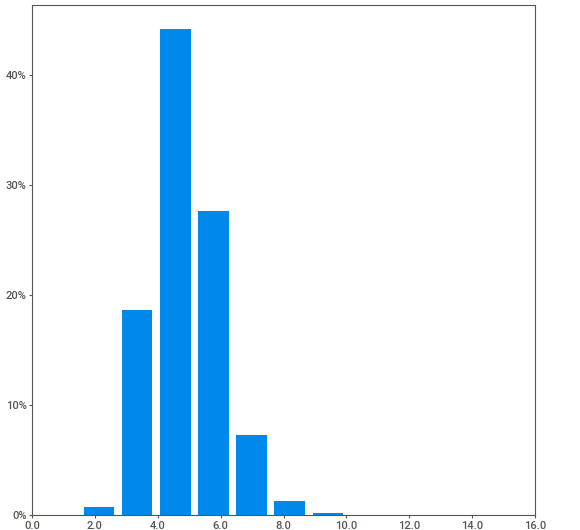
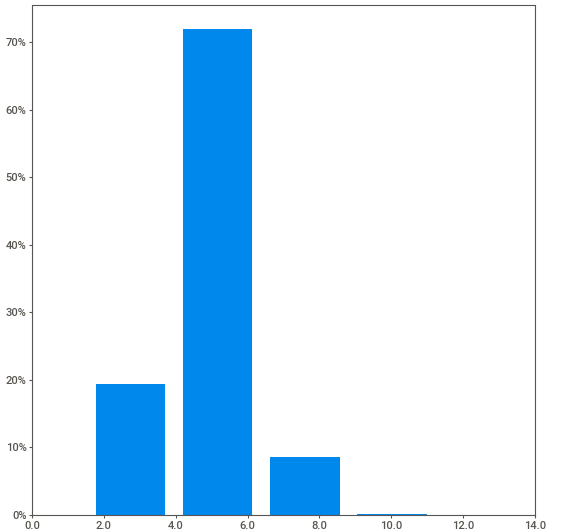
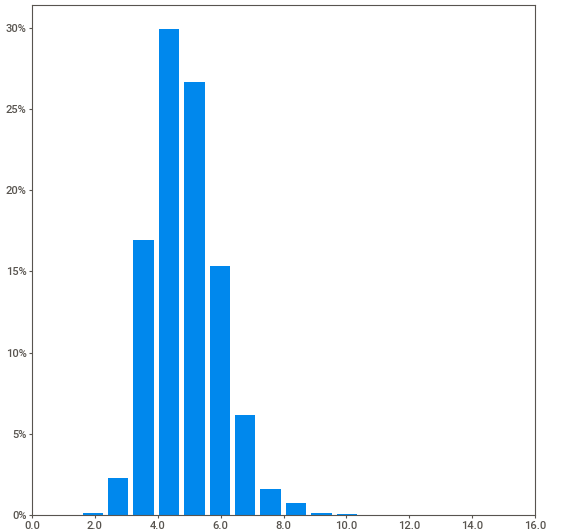
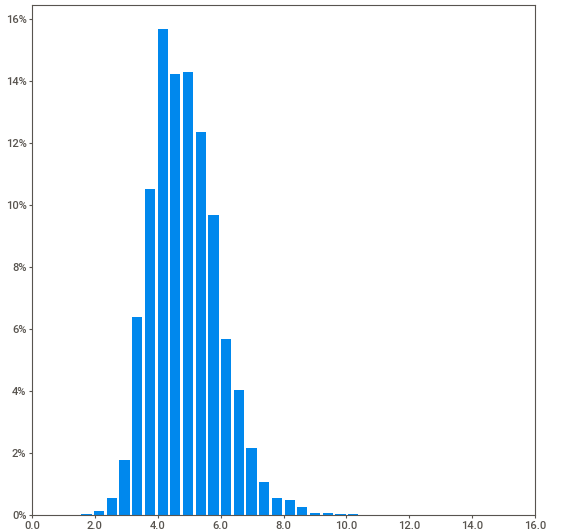
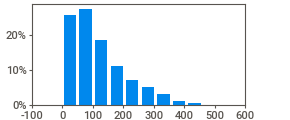
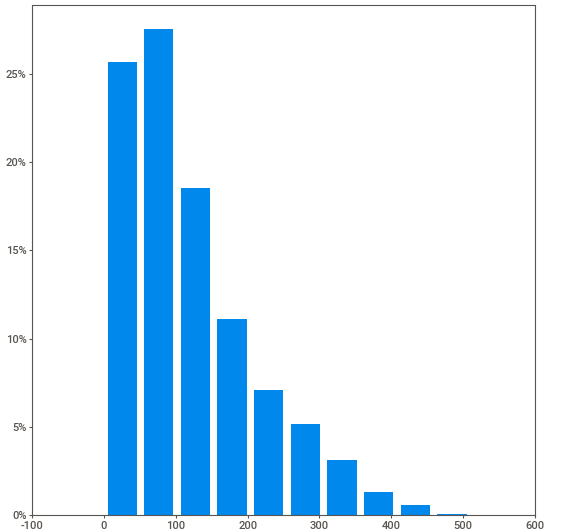
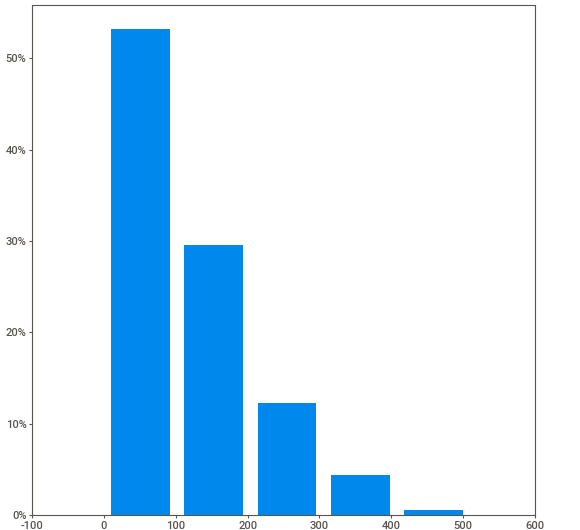
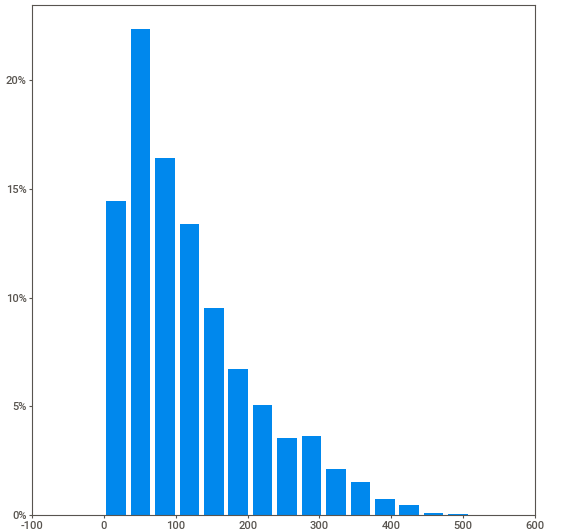
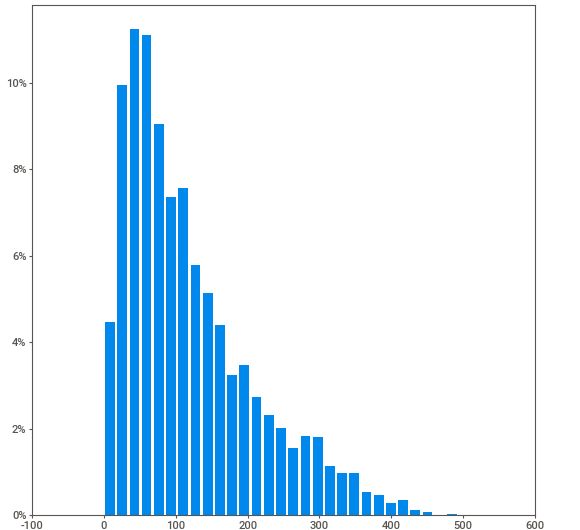
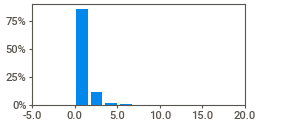
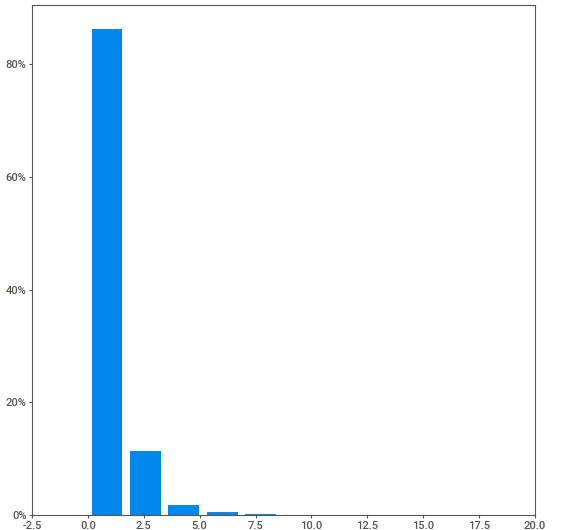
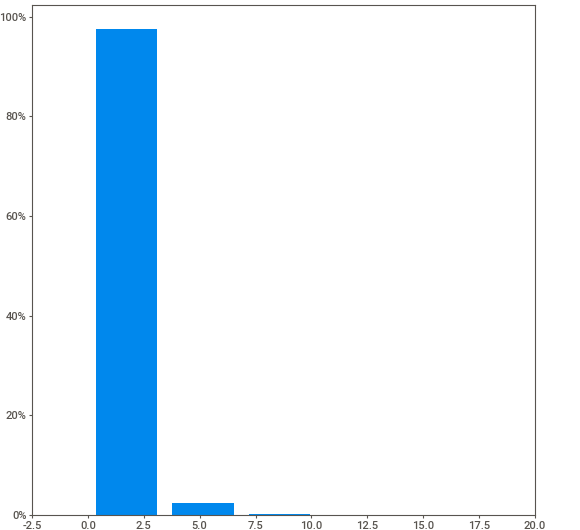
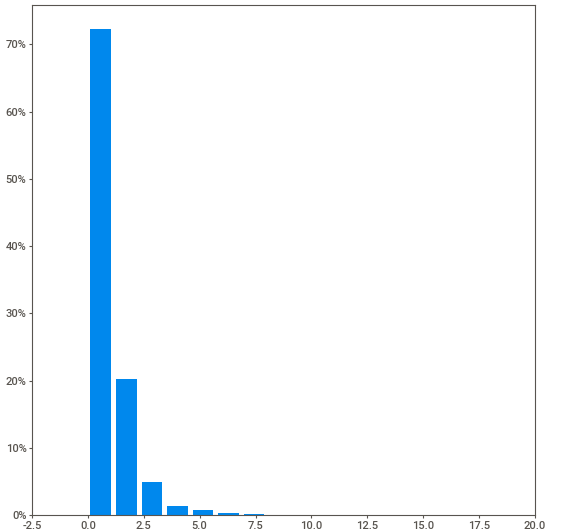
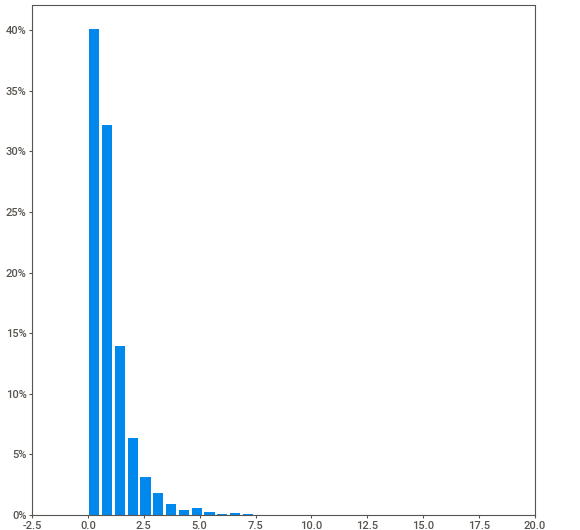
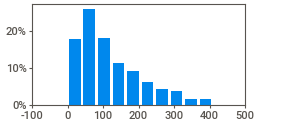
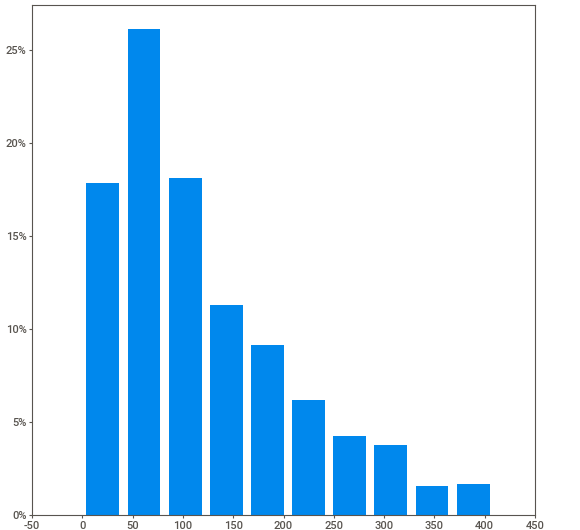
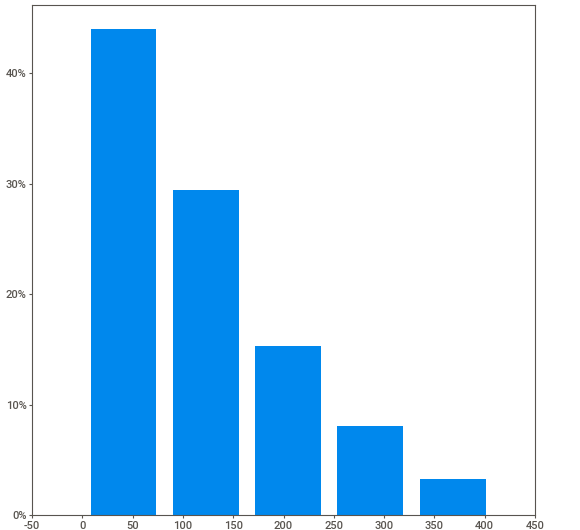
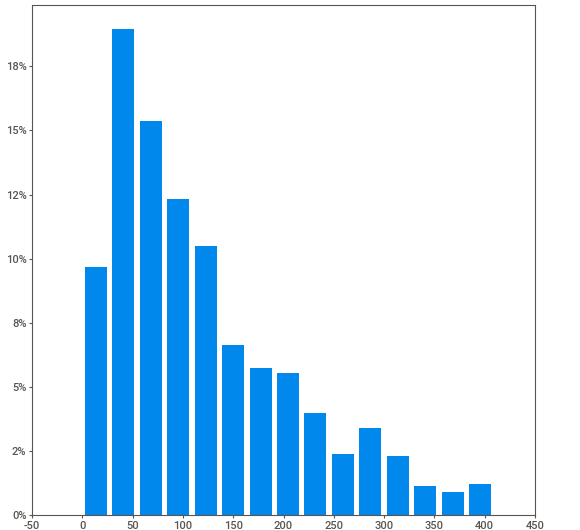
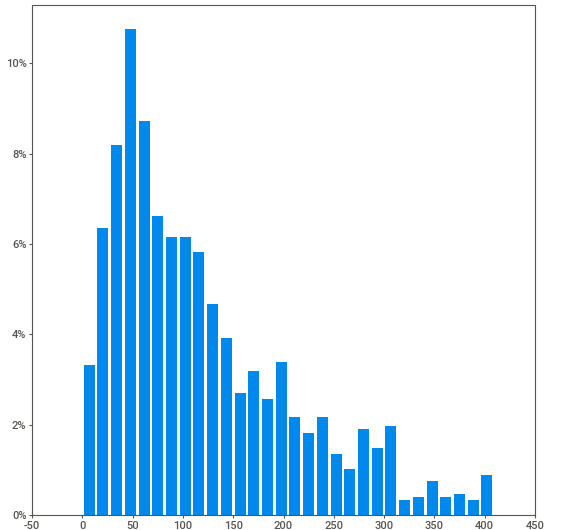
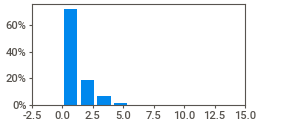
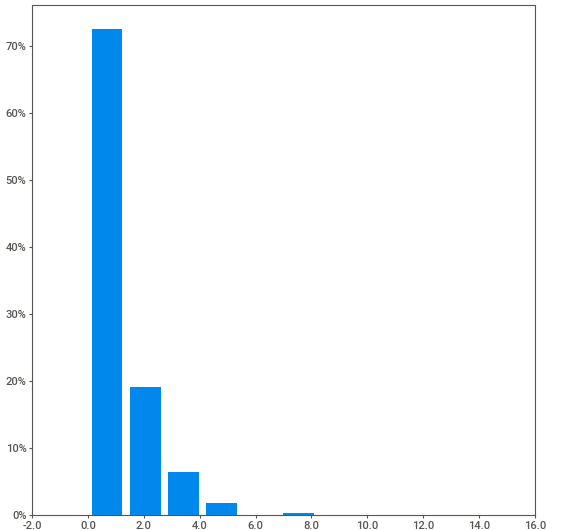
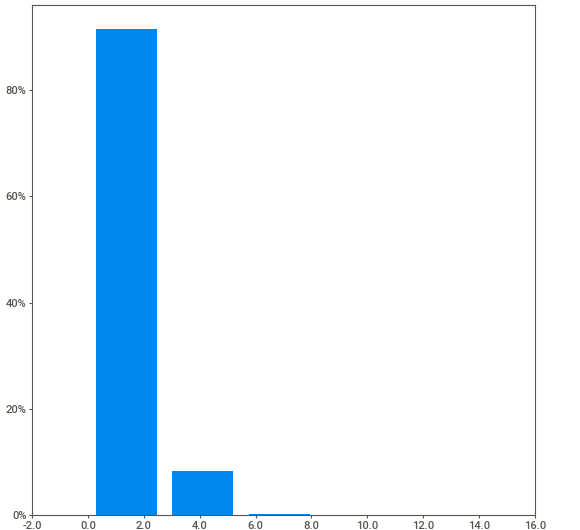
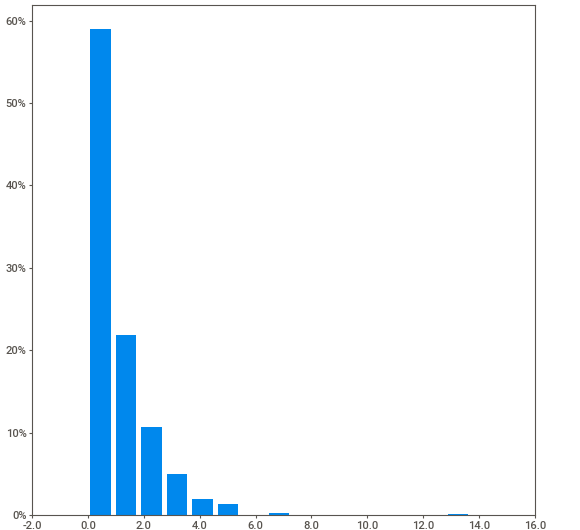
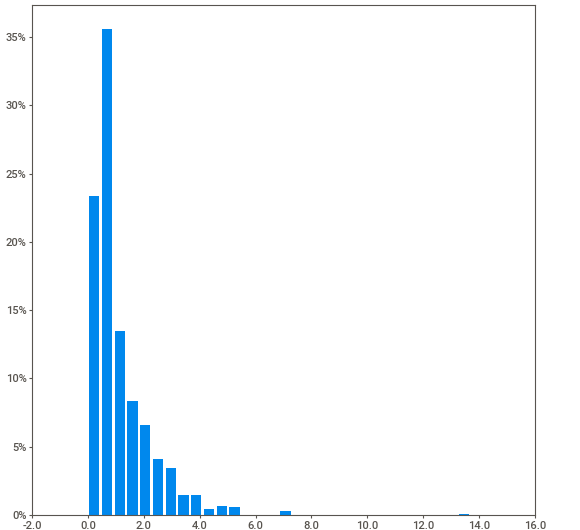
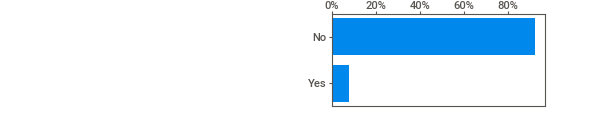
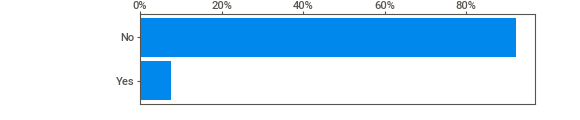
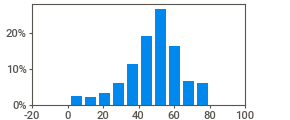
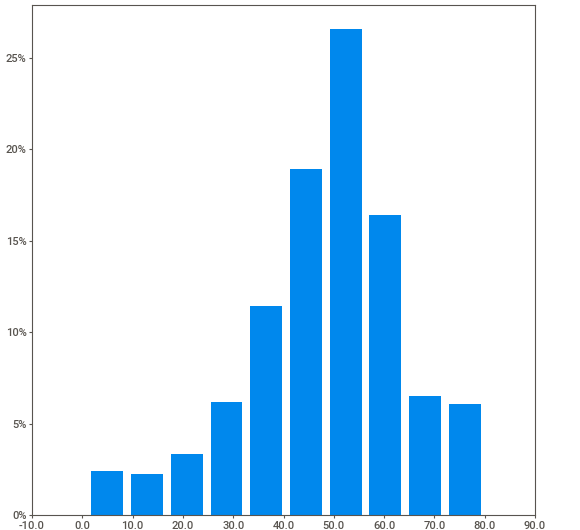
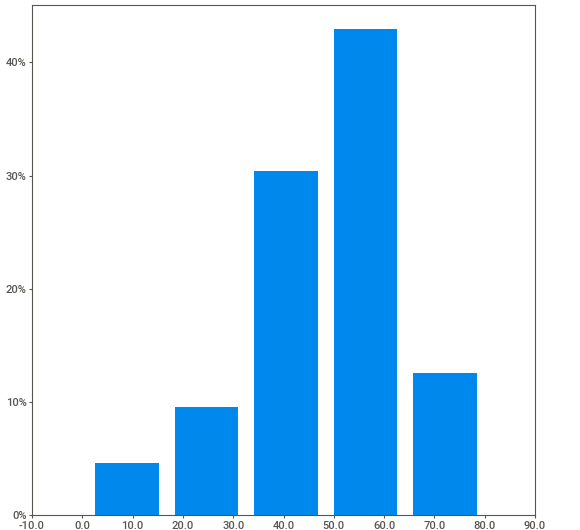
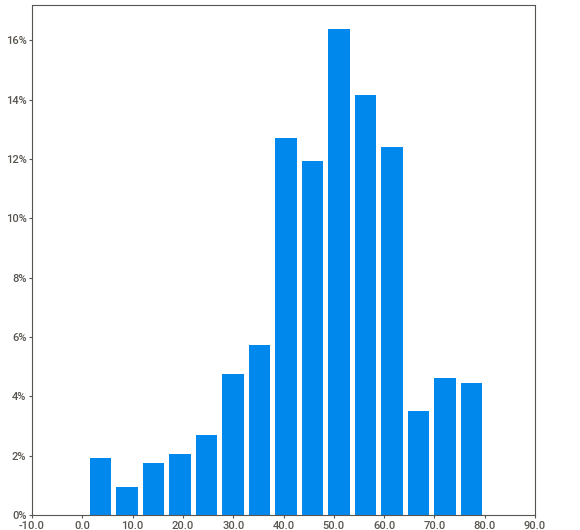
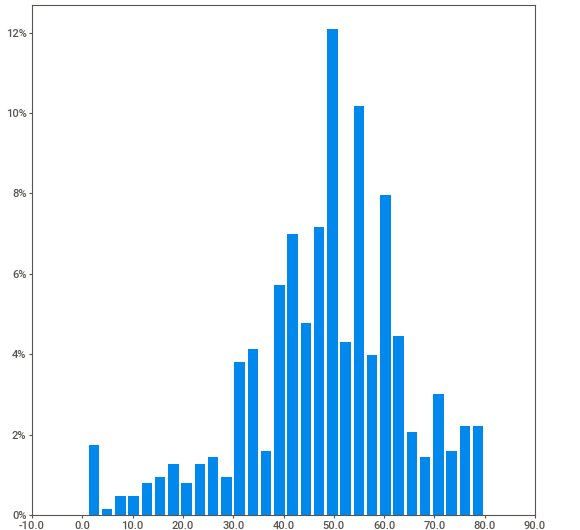
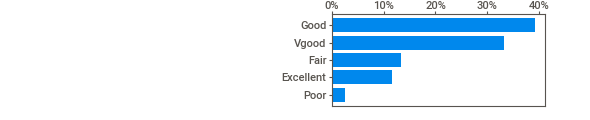
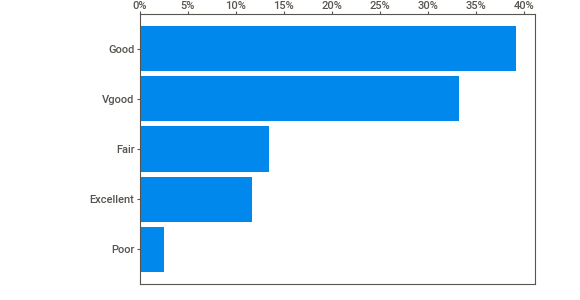
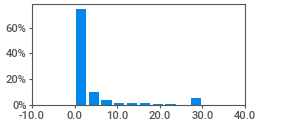
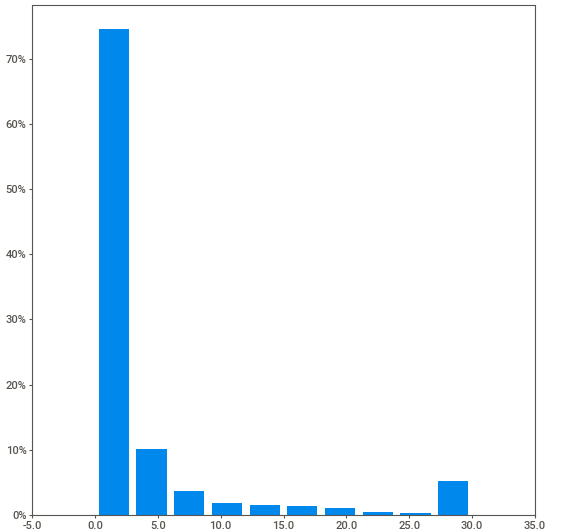
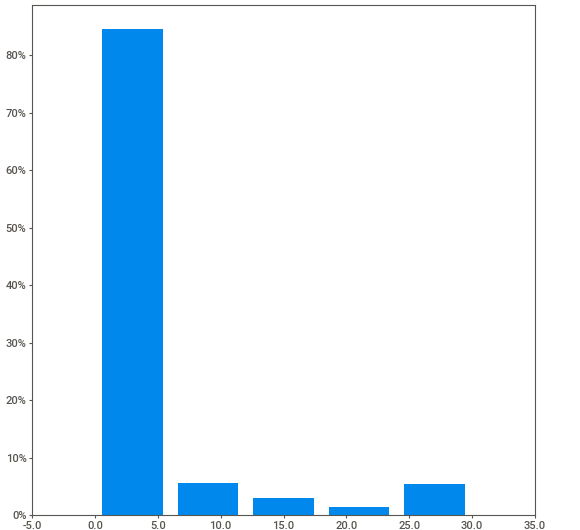
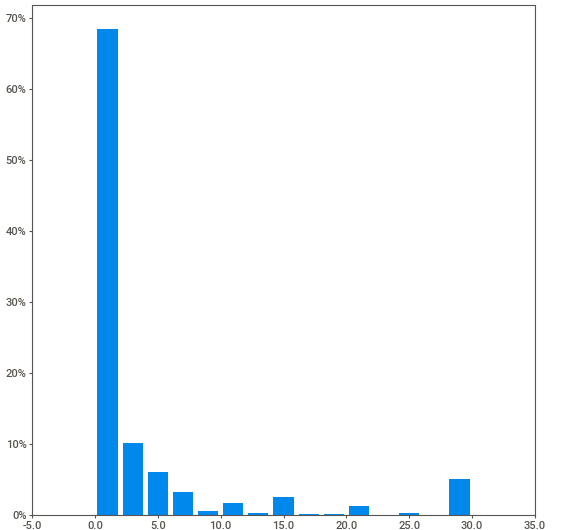
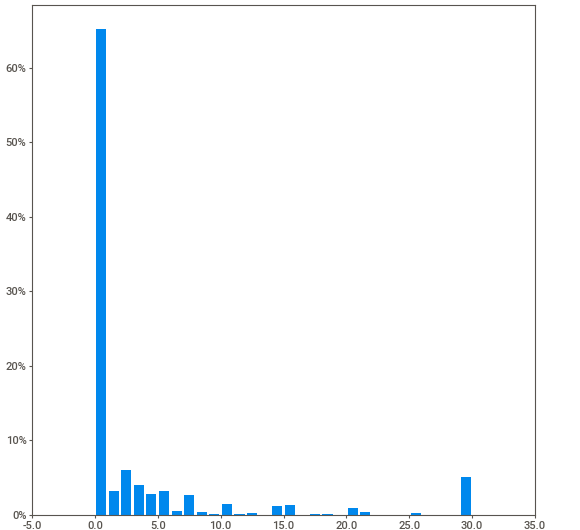
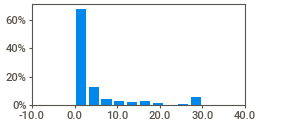
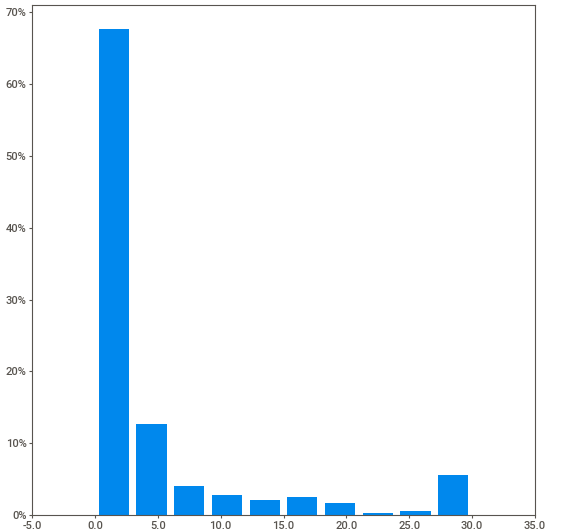
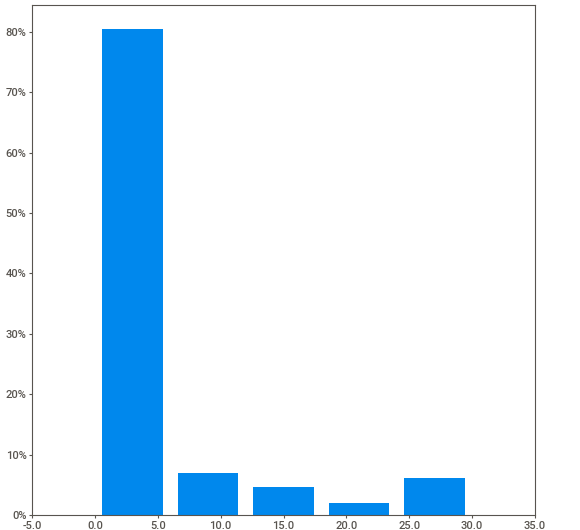
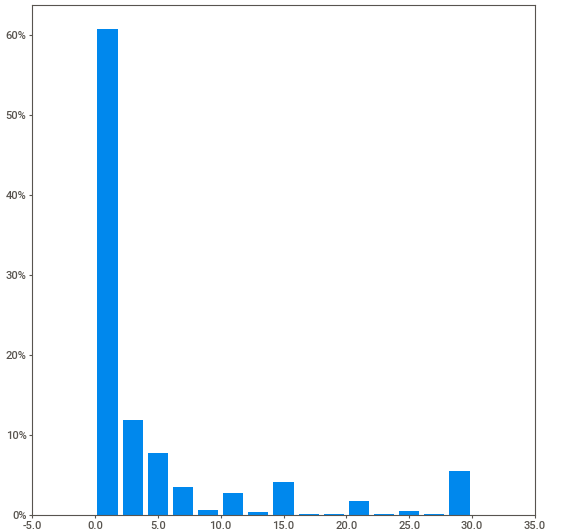
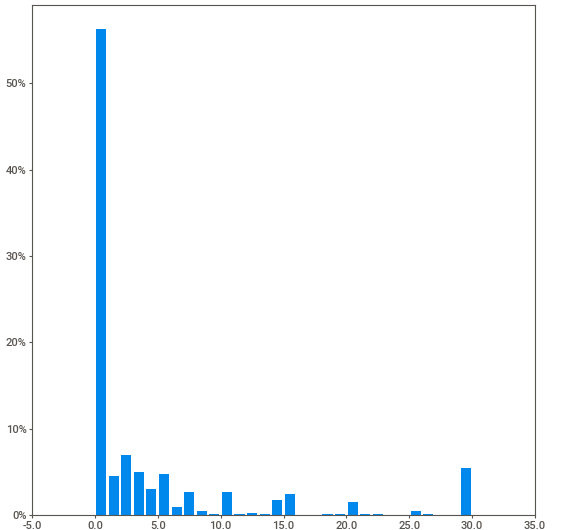
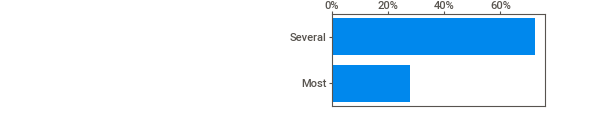
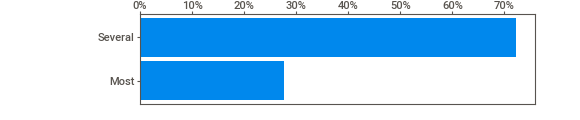
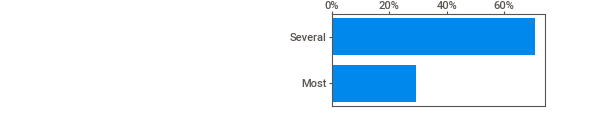
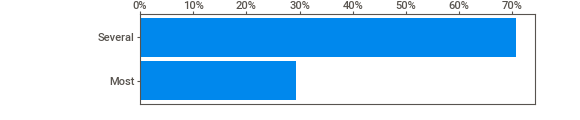
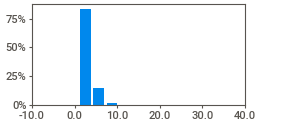
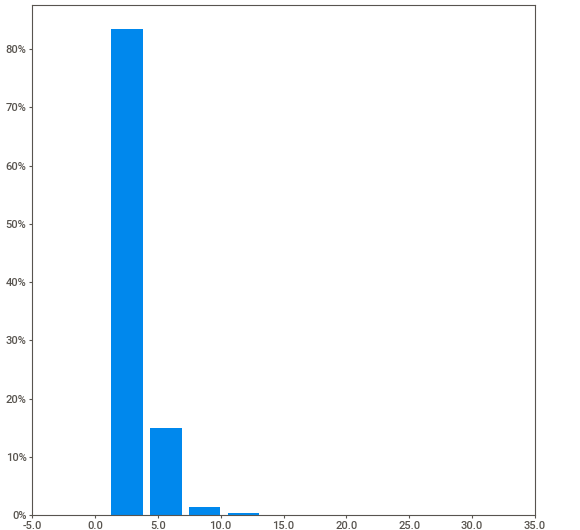
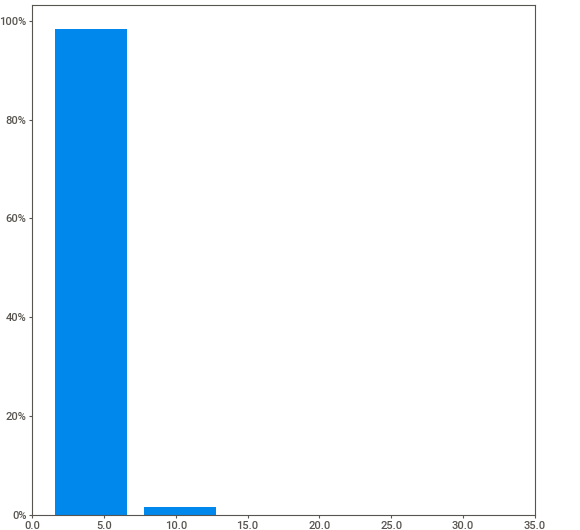
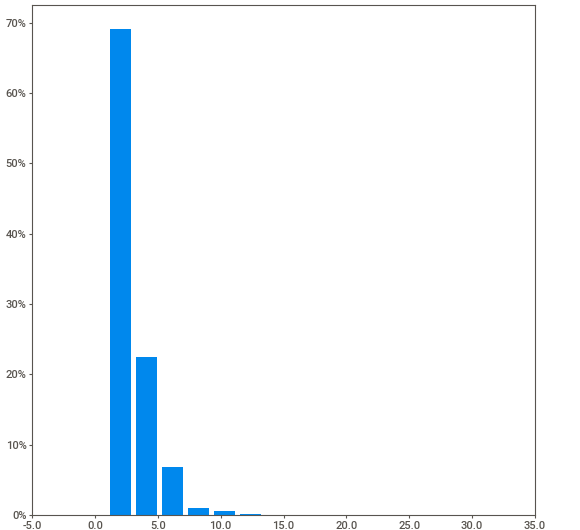
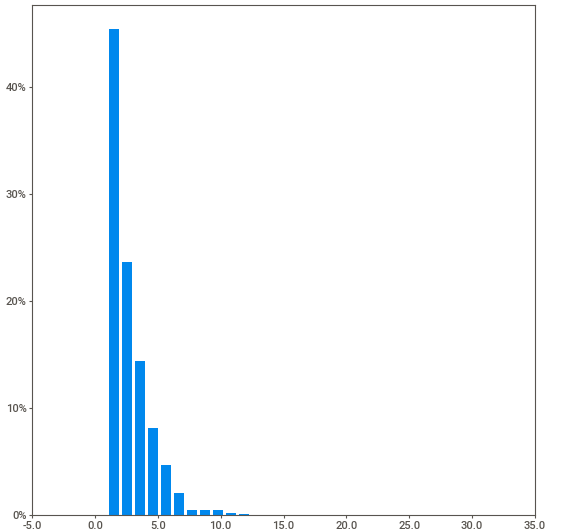
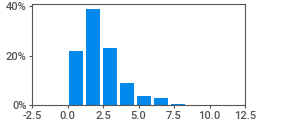
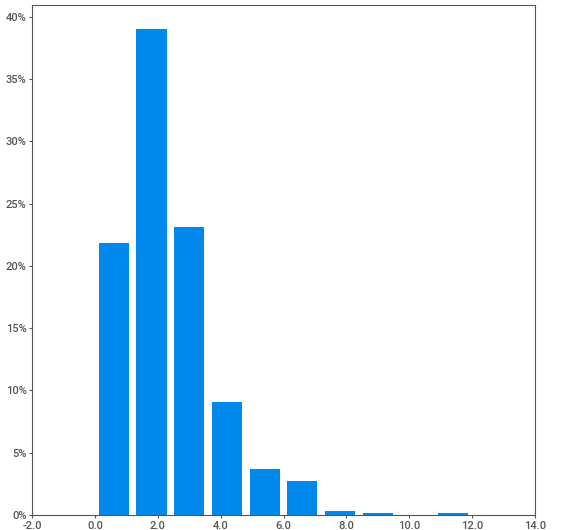
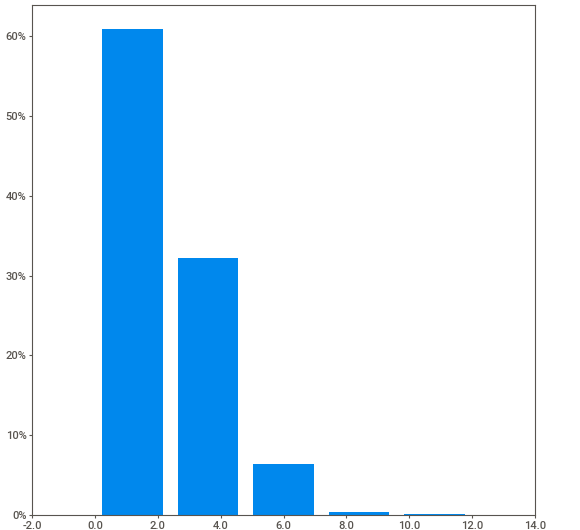
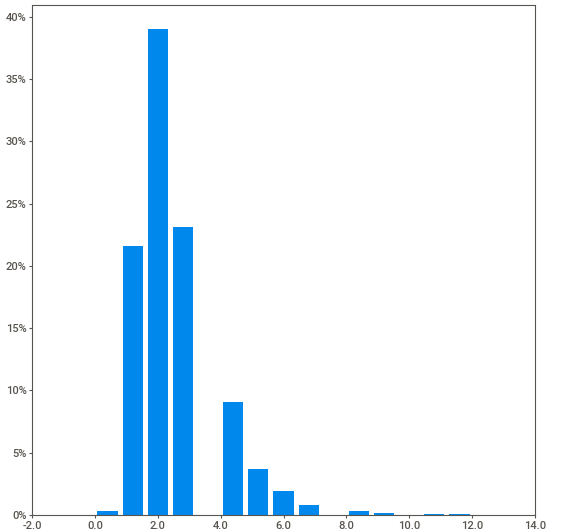
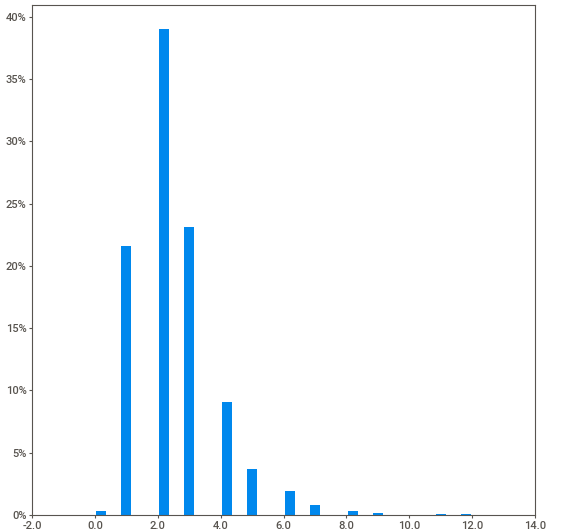
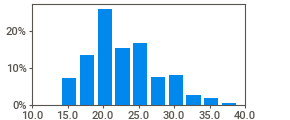
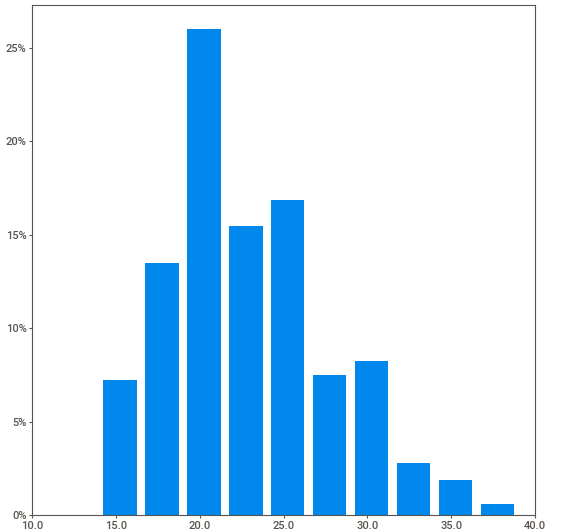
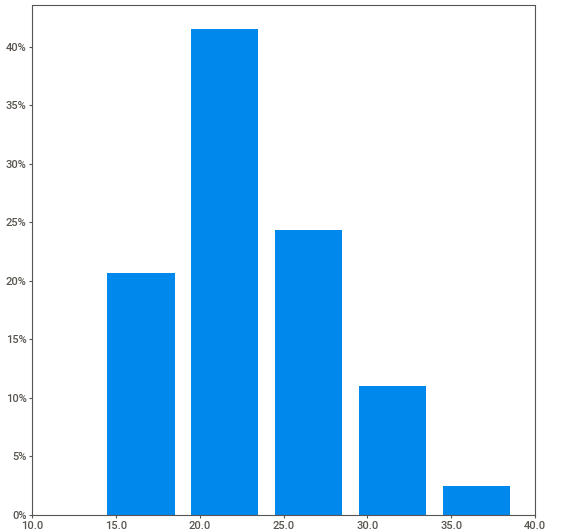
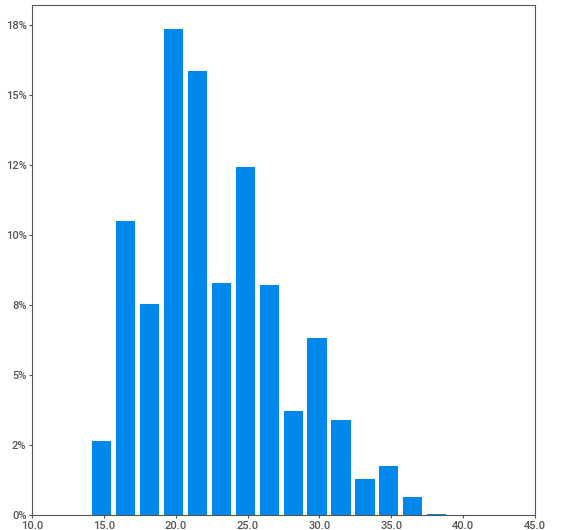
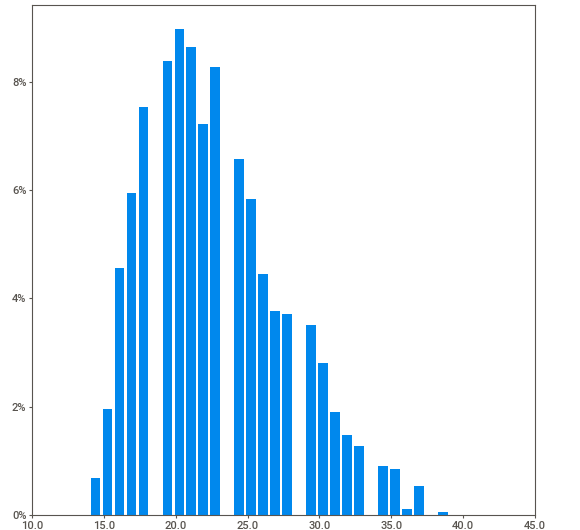
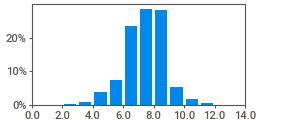
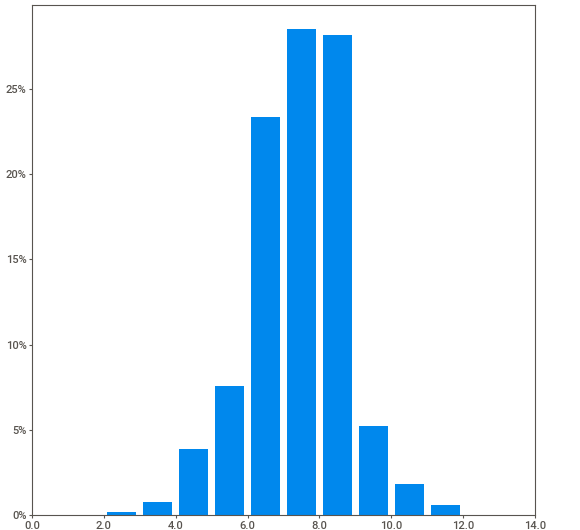
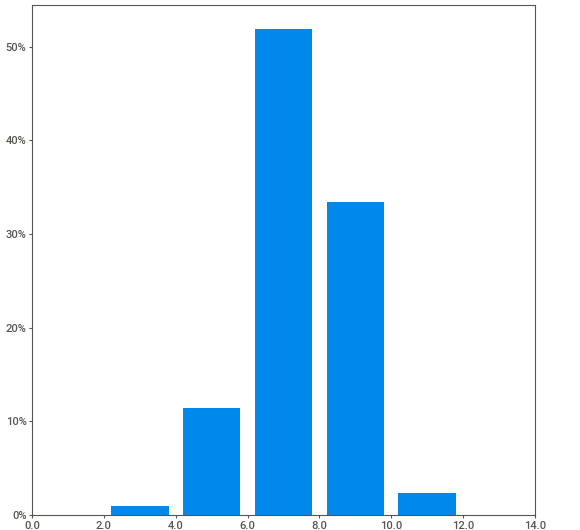
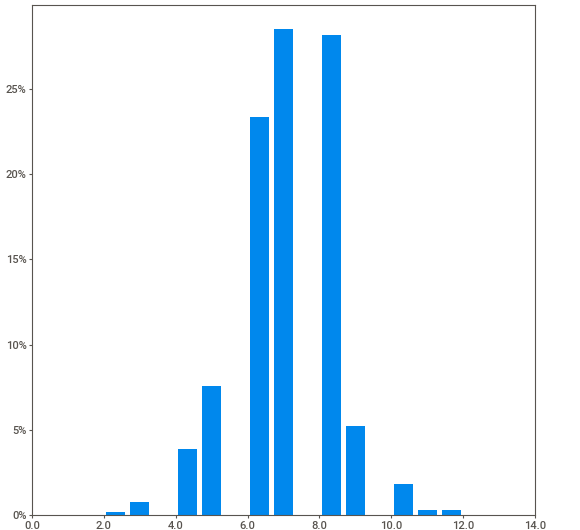
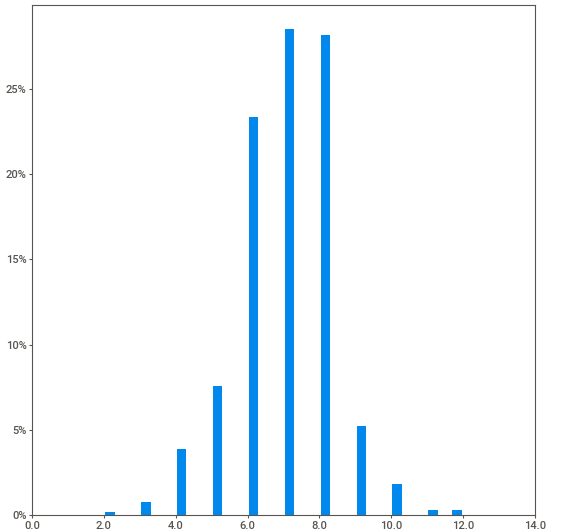
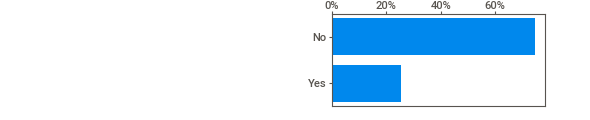
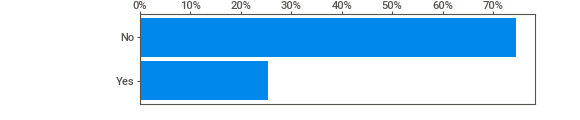
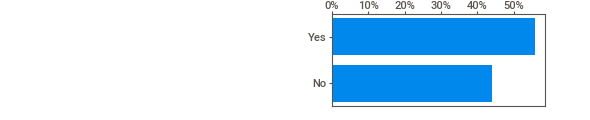
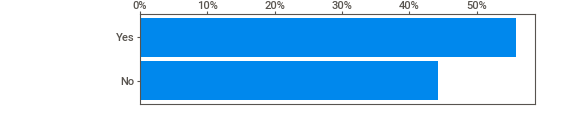
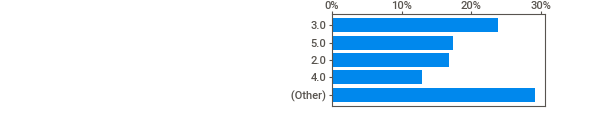
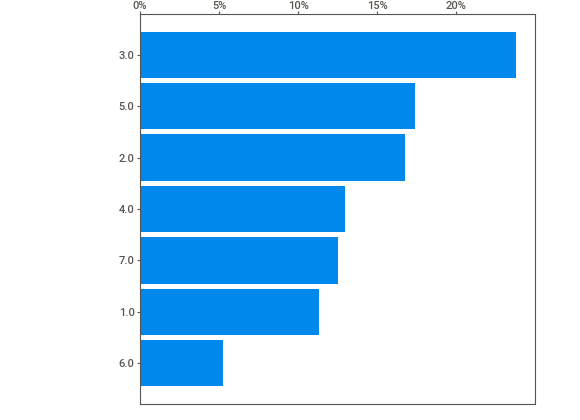
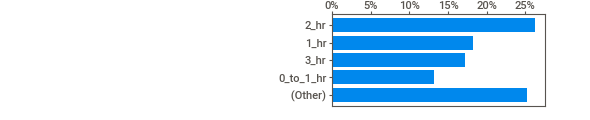
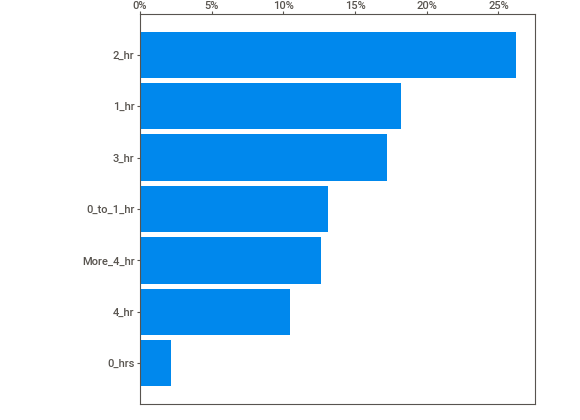
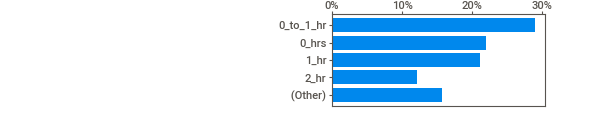
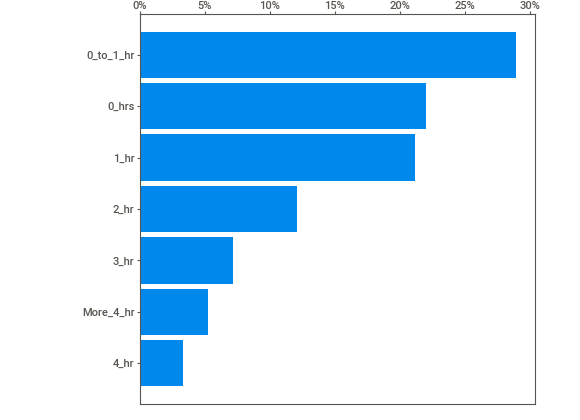
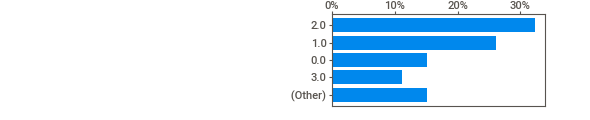
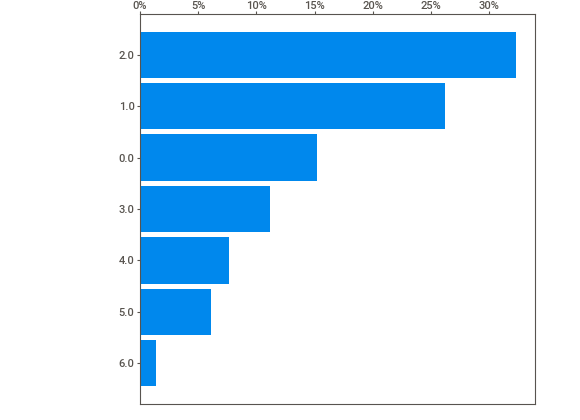
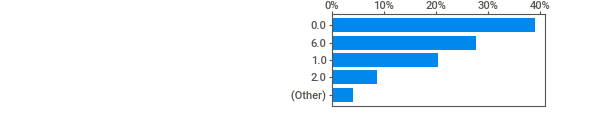
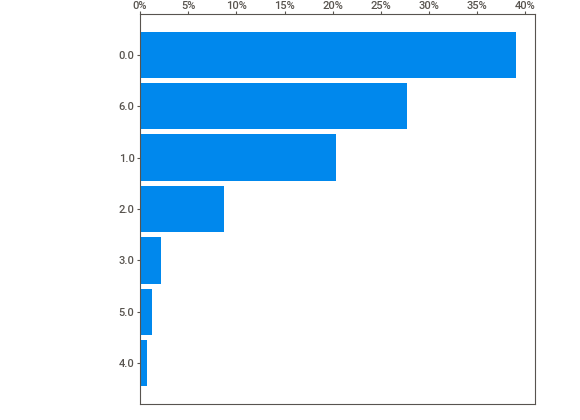
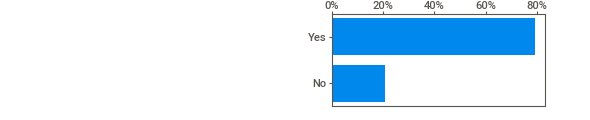
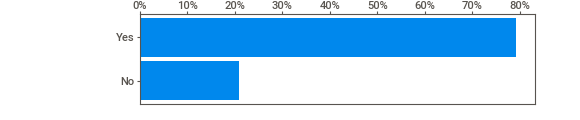
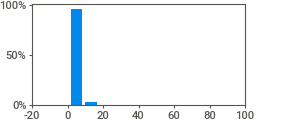
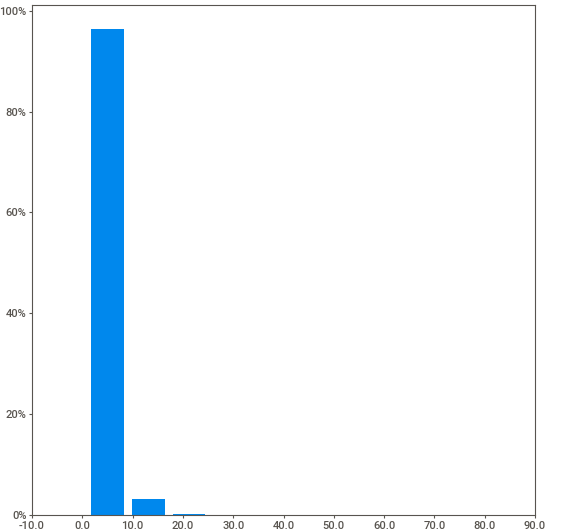
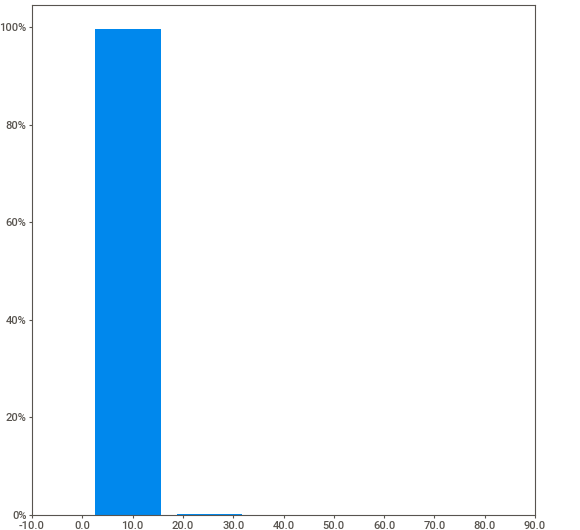
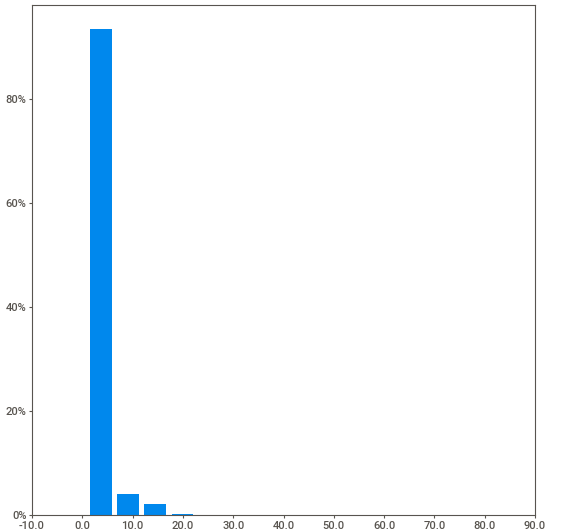
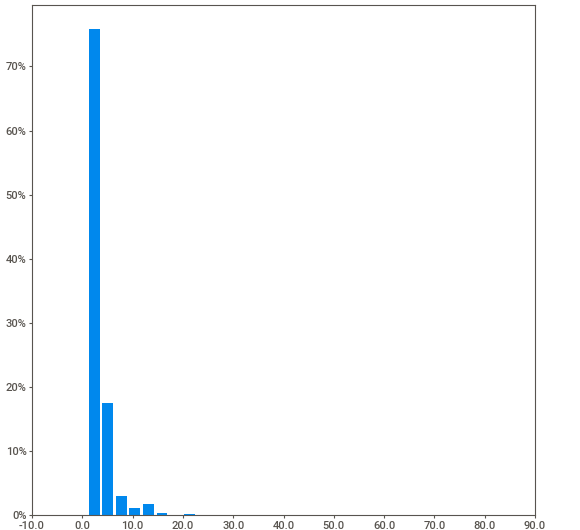
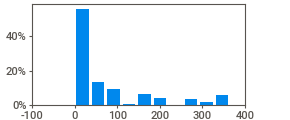
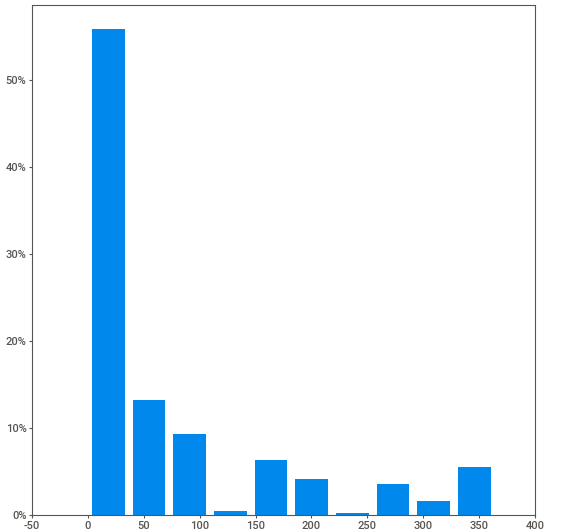
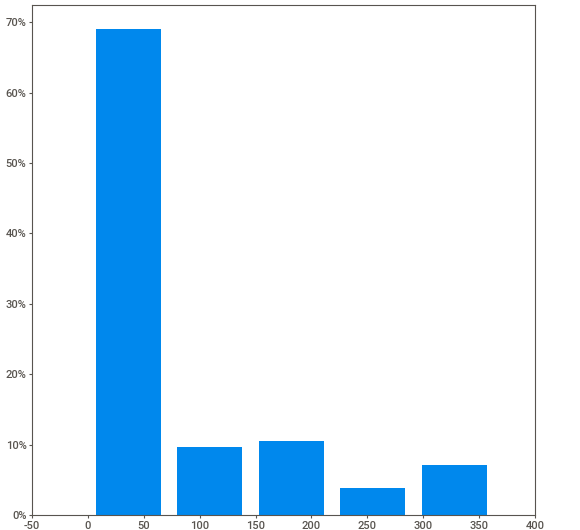
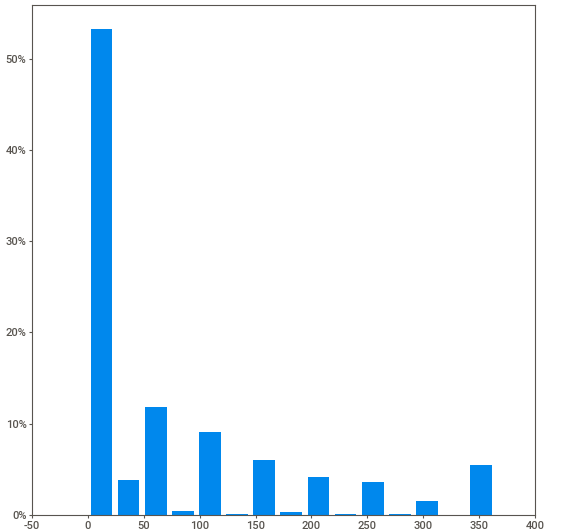
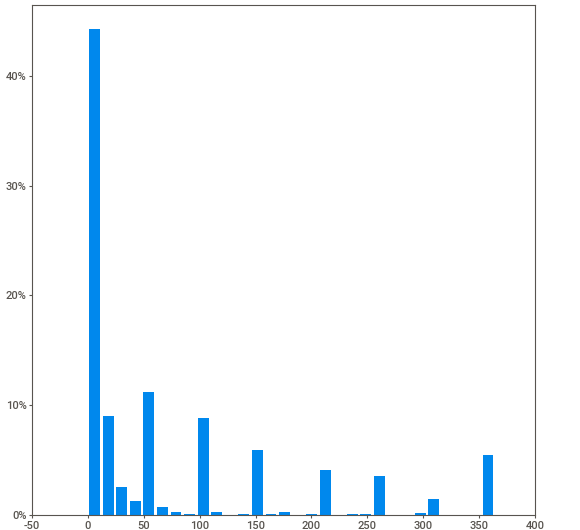
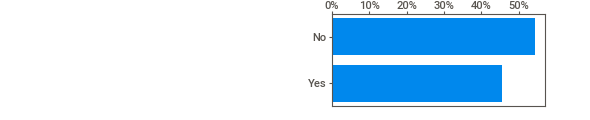
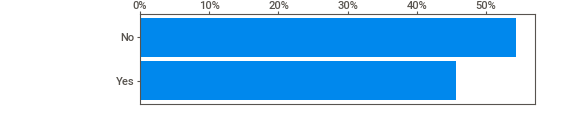
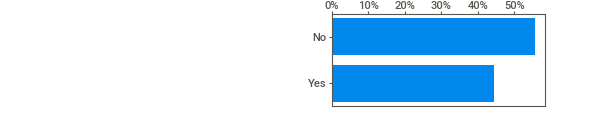
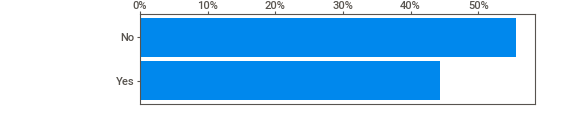
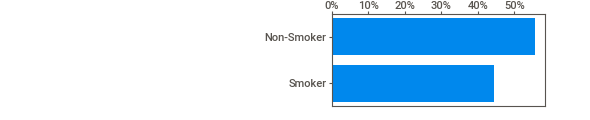
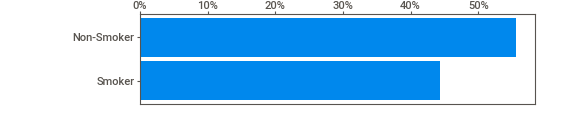
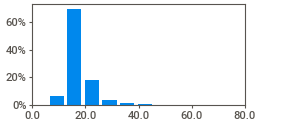
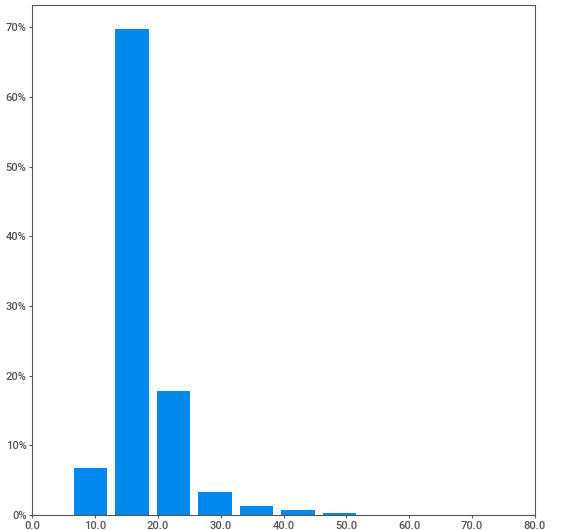
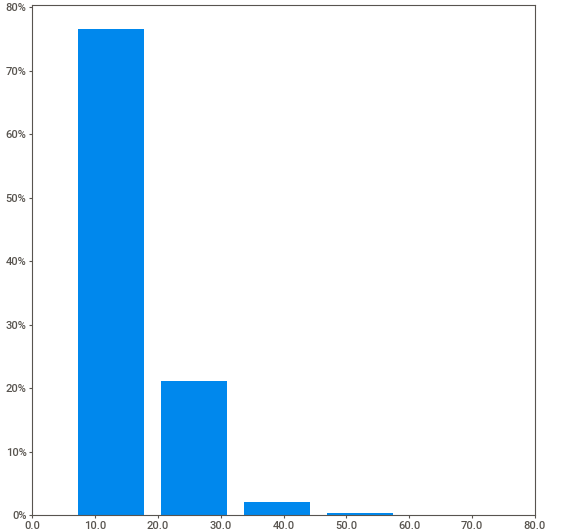
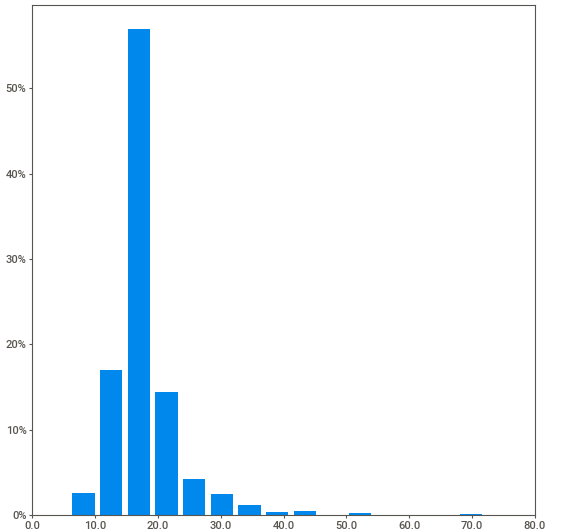
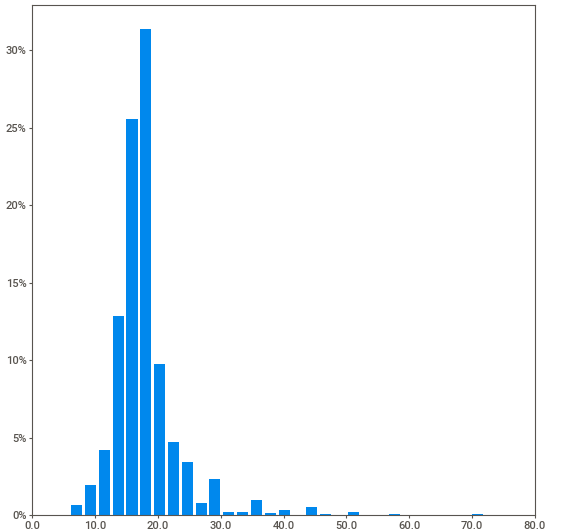
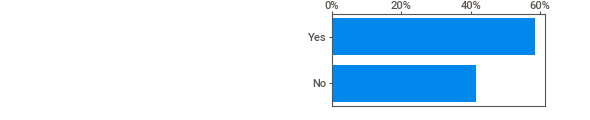
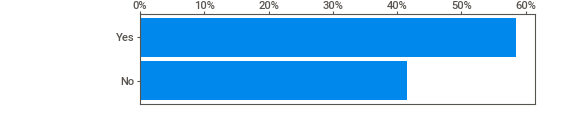
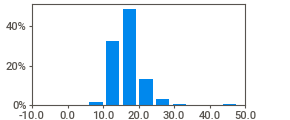
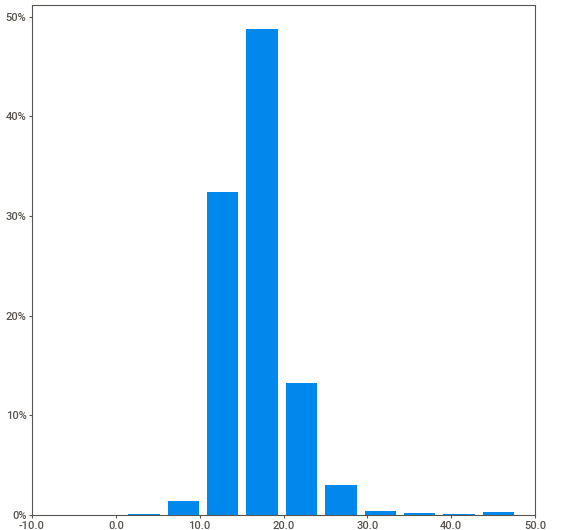
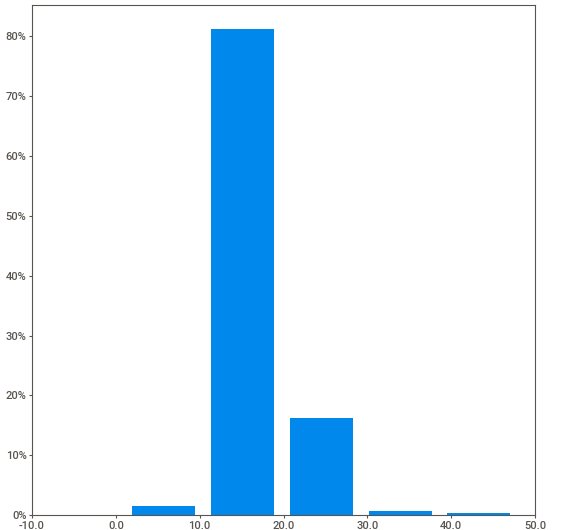
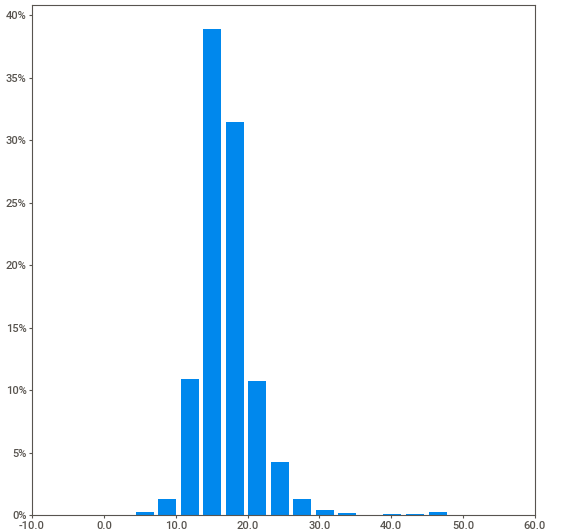
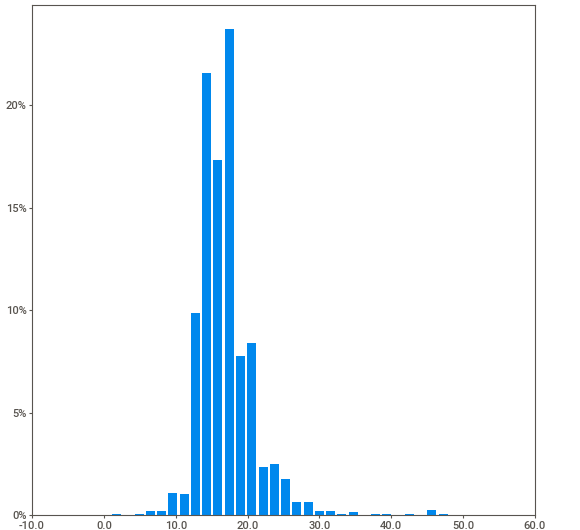
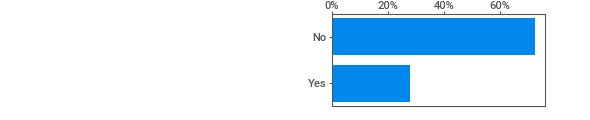
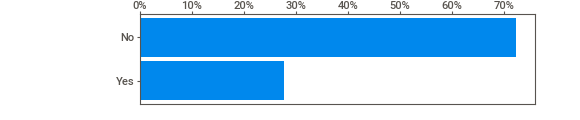
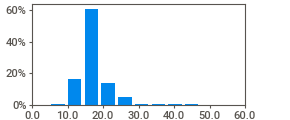
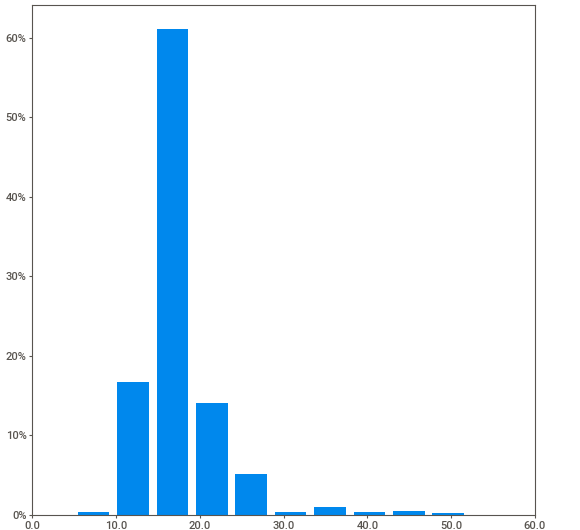
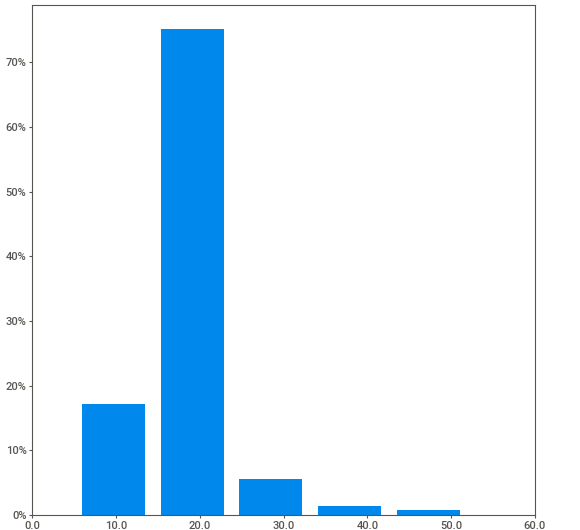
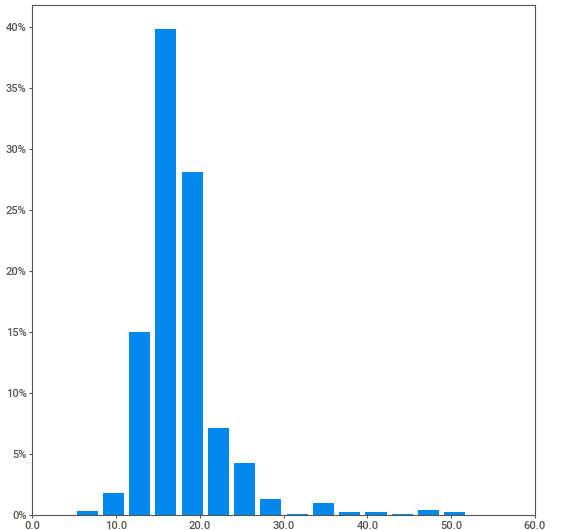
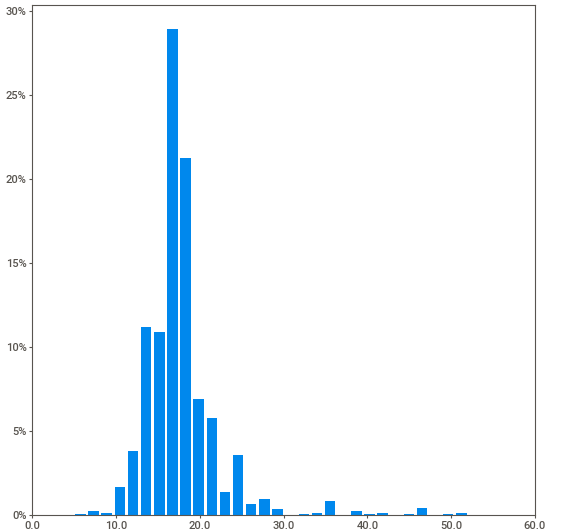
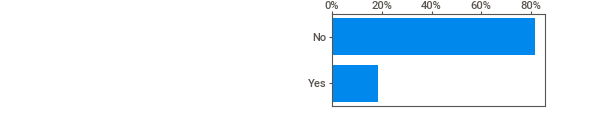
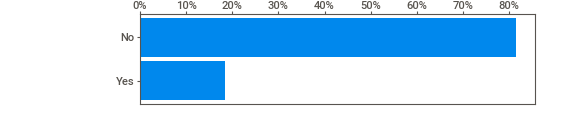
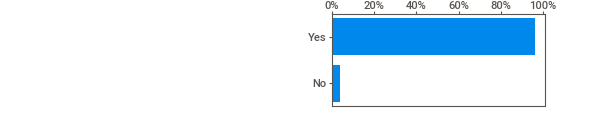
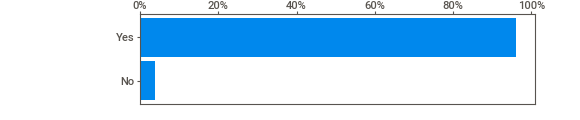
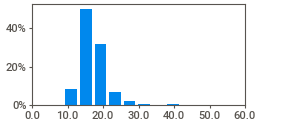
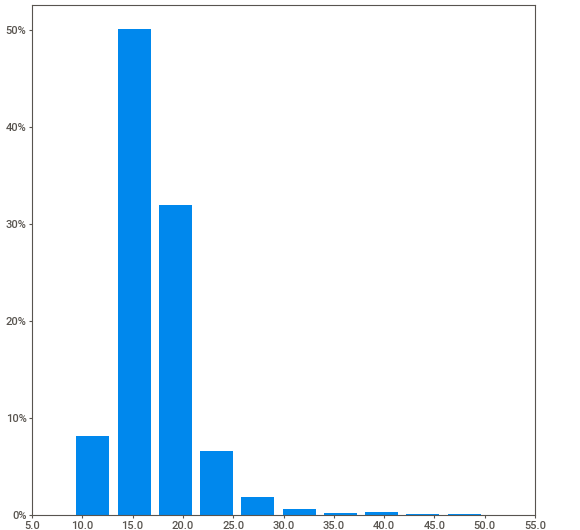
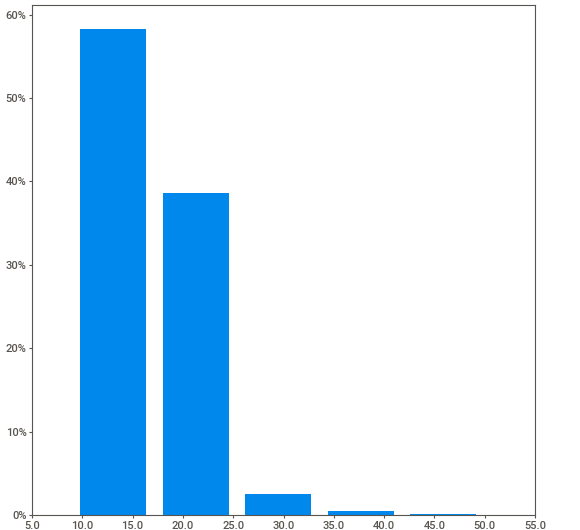
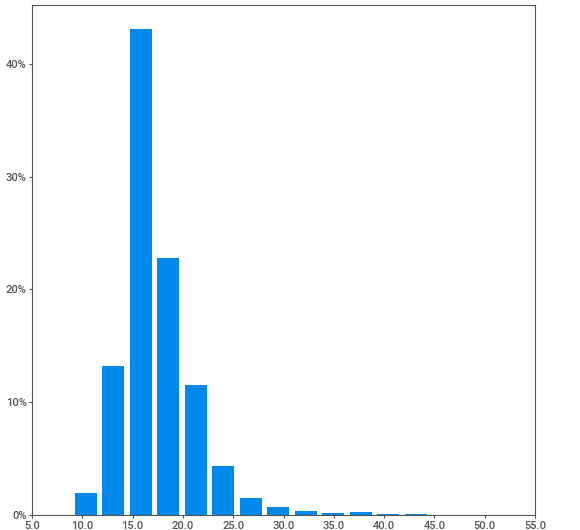
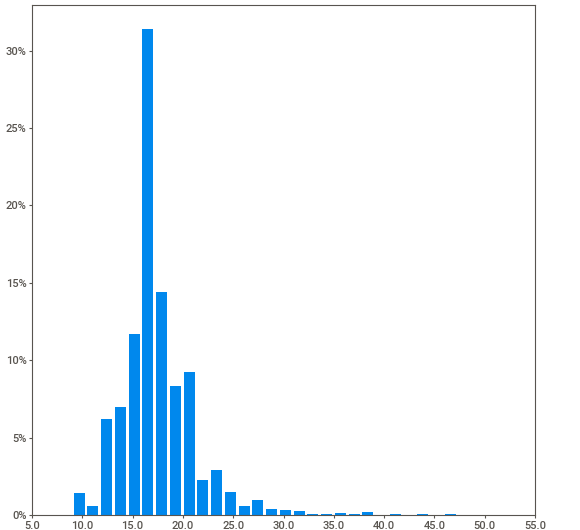
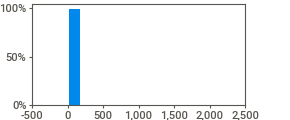
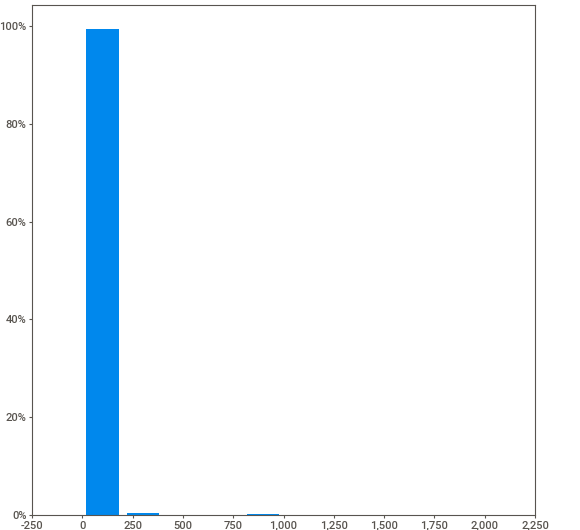
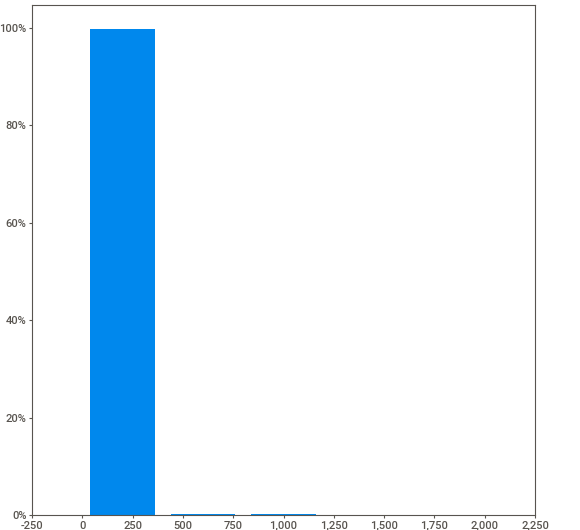
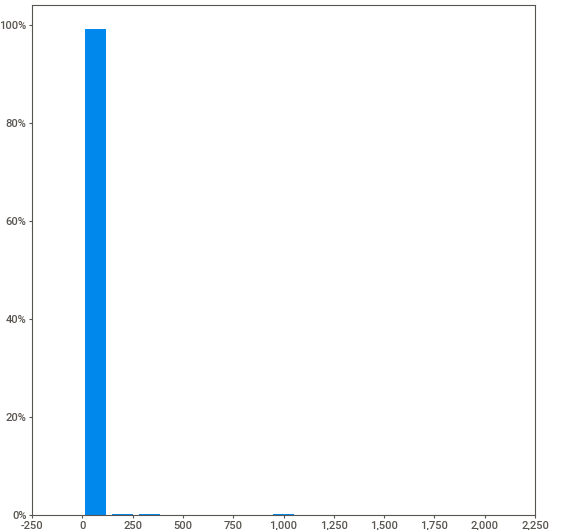
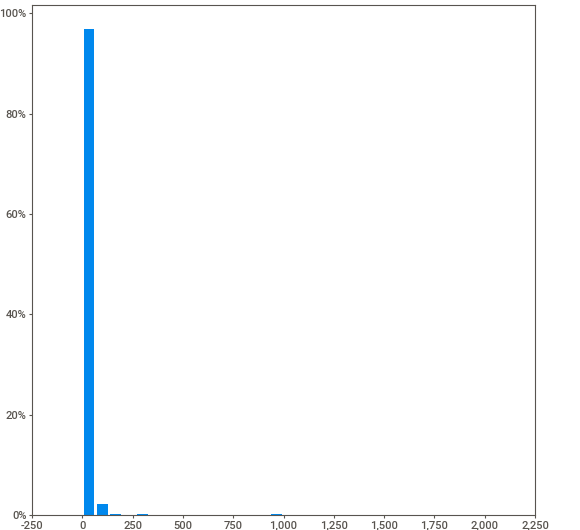
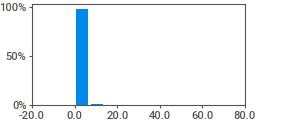
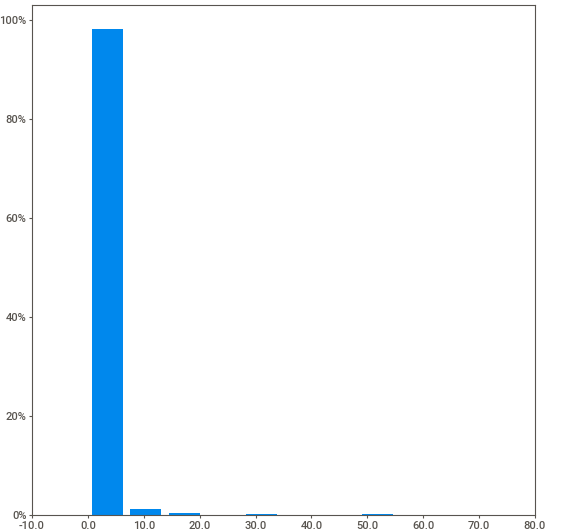
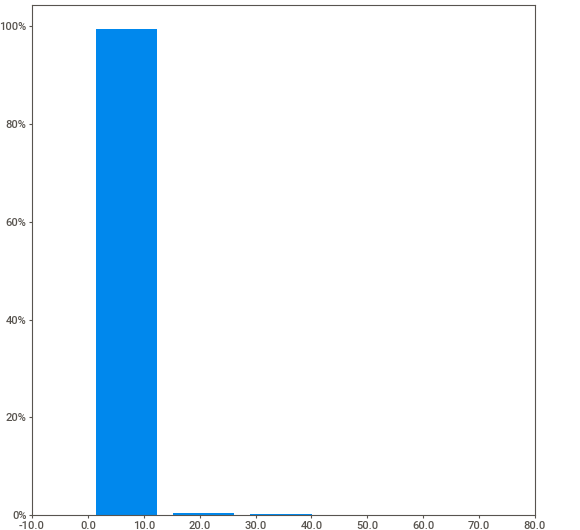
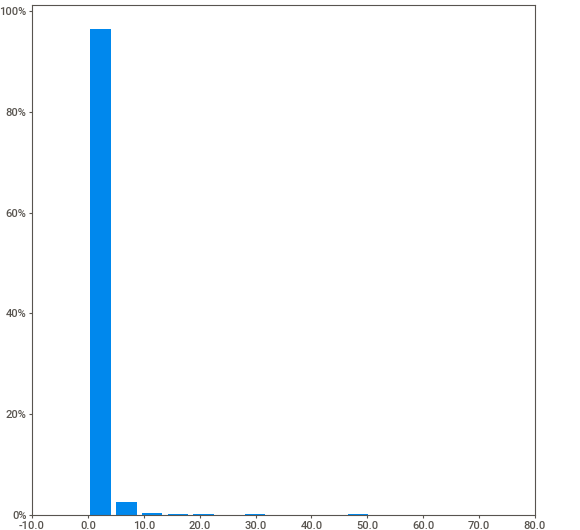
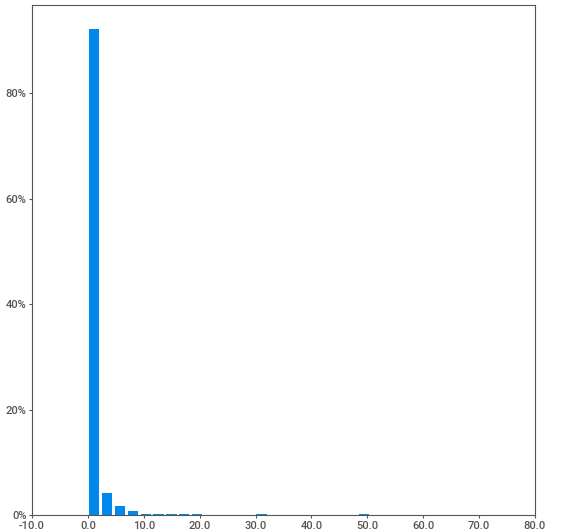
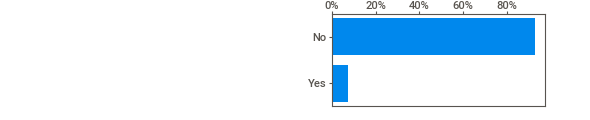
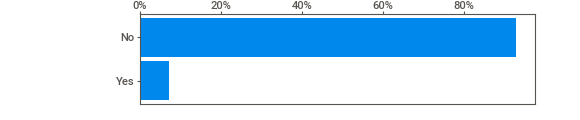
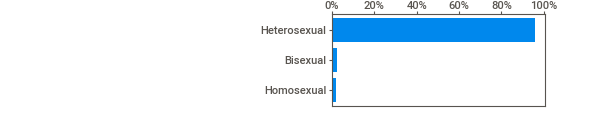
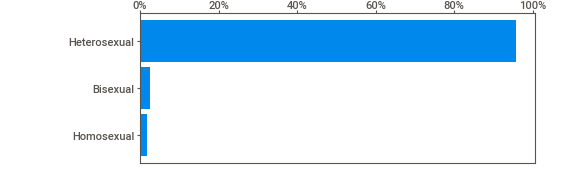
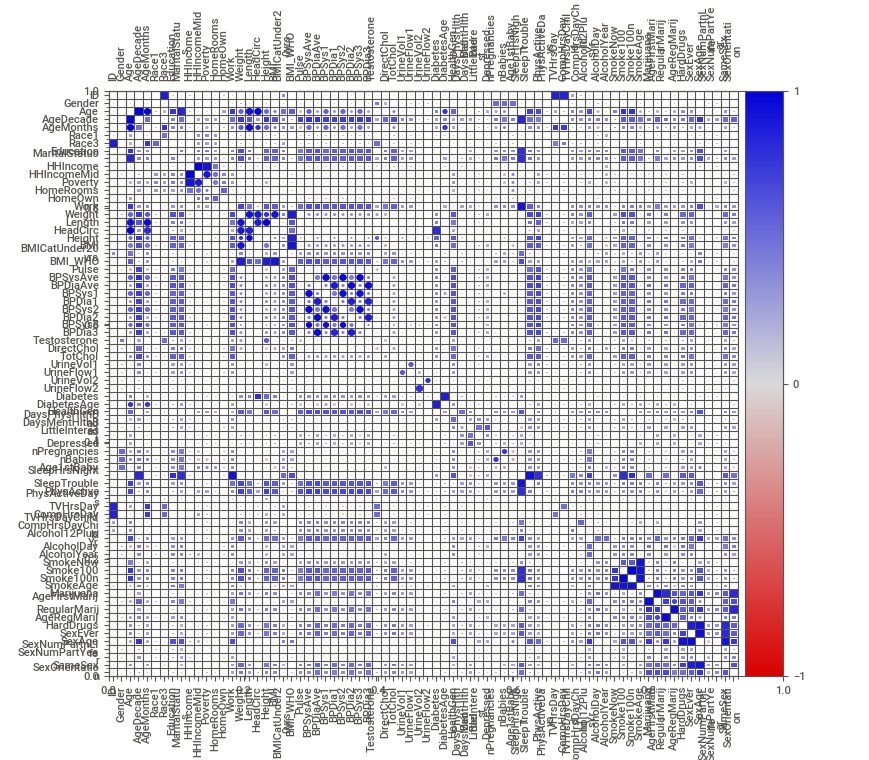
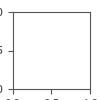

(likely due to only a single row containing non-NaN values for both correlated features)
Affected correlations:['Age/HeadCirc', 'HeadCirc/Age']


In [ ]:
report = sv.analyze(tips)
report.show_notebook()

In [ ]:
from google.colab import files
report.show_html('reporte_sweetviz.html')
files.download('reporte_sweetviz.html')

Report reporte_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
---
(likely due to only having a single row, containing non-NaN values for both correlated features)
Affected correlations:['Age/HeadCirc', 'HeadCirc/Age']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Es posible comparar diferentes cortes de base. Por ejemplo, compare el subconjunto de fumadores y no fumadores:

In [ ]:
report = sv.compare_intra(tips,tips["smoker"] == "Yes",["Smoker","No Smoker"])
report.show_notebook()

O el subconjunto de clientes masculinos y femeninos:

In [ ]:
report = sv.compare_intra(tips,tips["sex"] == "Male",["Male","Female"])
report.show_notebook()

O los subgrupos de almuerzo y cena:

In [ ]:
report = sv.compare_intra(tips,tips["time"] == "Dinner",["Dinner","Lunch"])
report.show_notebook()

### Impacto de los valores perdidos

Para ilustrar la diferencia entre los mecanismos de valor perdido, simulemos diferentes mecanismos de valor perdido y comparemos bases de datos. Inicialmente haremos una copia de la base de datos:

In [ ]:
tips_NA = tips.copy()

Y luego seleccionamos una muestra aleatoria del 20%,

In [ ]:
sample = np.random.choice(list(tips_NA.index),int(len(tips)*0.2))
tips_NA.loc[sample,['total_bill','tip']] = np.nan

Comparemos los dos conjuntos de datos:

In [ ]:
report = sv.compare([tips,"Original"],[tips_NA,"Ausentes"])
report.show_notebook()

Una de las técnicas utilizadas para lidar con datos faltantes es eliminar las filas que contienen un valor faltante, utilizando la función `.dropna ()`.

In [ ]:
tips_removido = tips_NA.dropna()
report = sv.compare([tips,"Original"],[tips_removido,"Removido"])
report.show_notebook()

Datos faltantes con prioridad en las mesas para fumadores

In [ ]:
#crear una columnas de probabilidades, al inicio todos con probabilidad 1
p = np.ones(len(tips['smoker']))
# escojer la probabilidad de 0.5 para mesas de no fumadores
p[np.where(tips['smoker']=='No')] = 0.5
#calcular la probabilidad par cada item del dat set
p = p/sum(p)

In [ ]:
tips_NA2 = tips.copy()
sample = np.random.choice(list(tips_NA2.index),int(len(tips)*0.2), p = p)
tips_NA2.loc[sample,['total_bill','tip']] = np.nan

In [ ]:
report = sv.compare([tips_NA,"MCAR"],[tips_NA2,"MAR"])
report.show_notebook()

In [ ]:
tips_removido2 = tips_NA2.dropna()
report = sv.compare([tips_removido,"MCAR"],[tips_removido2,"MAR"])
report.show_notebook()

## 4.- Investigue alguna otra herramienta similar a sweetviz para hacer el EDA. Realice el EDA con la herramienta investigada. Y haga un análisis comparativo de ambas herramientas.